In [45]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch


from matplotlib.lines import Line2D

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PRED_ROOT = Path('predicted_rerun_fixed')


In [3]:
base = Path("predicted_rerun_fixed")          # change if your path differs
shots = [48, 64, 96, 144, 192, 240]
seeds = list(range(1, 6))

mode = "position-specific"
ainit = -1.0
ainit_str = str(ainit)                        # "-1.0"
combined = "scores"
trainmode = "full"

if not base.exists():
    print(f"ERROR: {base} not found. Set correct base path.")

In [4]:
results = {}
protein_dirs = [p for p in base.iterdir() if p.is_dir()]
proteins_with_data = set()

for shot in shots:
    rhos = {}
    for prot_dir in protein_dirs:
        preds_for_prot = pd.DataFrame()
        for seed in seeds:
            subdir = (f"shot{shot}_seed{seed}_mode{mode}_ainit{ainit_str}"
                    f"_combined{combined}_trainmode{trainmode}")
            pred_path = prot_dir / subdir / "pred.csv"
            if not pred_path.exists():
                continue
            try:
                temp_df = pd.read_csv(pred_path)
                temp_df = temp_df.set_index(temp_df["mutation"]).drop_duplicates()
                if preds_for_prot.empty:
                    preds_for_prot = pd.DataFrame(index=temp_df.index)
                    preds_for_prot["ytrue"] = temp_df.iloc[:, 2]

                preds_for_prot[seed] = temp_df.iloc[:, 0]
            except Exception as e:
                print(f"Error reading {pred_path}: {e}")
                continue
        if len(preds_for_prot) >= 1 and "ytrue" in preds_for_prot.columns:
            seed_cols = [c for c in preds_for_prot.columns if c != "ytrue"]
            avg_pred = preds_for_prot[seed_cols].mean(axis=1)
            ytrue = preds_for_prot["ytrue"]
            rho, _ = spearmanr(avg_pred, ytrue)
            rhos[prot_dir.name] = rho
            proteins_with_data.add(prot_dir)
    results[shot] = rhos


In [5]:
results_df = pd.DataFrame(results)

In [6]:
results_df

,48,64,96,144,192,240
GDIA_HUMAN_Silverstein_2021,0.508242,0.511237,0.513136,0.515956,0.513748,0.515245
R1AB_SARS2_Flynn_2022,0.393334,0.449407,0.471088,0.539410,0.549039,0.620546
NRAM_I33A0_Jiang_2016,0.619617,0.698194,0.743262,0.742873,0.772881,0.742206
BLAT_ECOLX_Jacquier_2013,0.789289,0.802458,0.795533,0.797752,0.809796,0.806643
A0A192B1T2_9HIV1_Haddox_2018,0.578877,0.592160,0.632586,0.645234,0.650248,0.691828
...,...,...,...,...,...,...
ANCSZ_Hobbs_2022,0.574763,0.602868,0.639160,0.685962,0.685878,0.698752
B2L11_HUMAN_Dutta_2010_binding-Mcl-1,0.732620,0.779679,0.747288,0.859435,0.859435,0.859435
HXK4_HUMAN_Gersing_2023_abundance,0.434965,0.441989,0.437955,0.457575,0.518493,0.512062
AACC1_PSEAI_Dandage_2018,0.559812,0.560298,0.560138,0.569814,0.562974,0.571245


In [7]:
np.sum(results_df.isna())

/work/shannon/miniconda3/envs/ml-base/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


48     0
64     0
96     0
144    0
192    0
240    0
dtype: int64

In [8]:
results_df.dropna().mean()

48     0.506912
64     0.524558
96     0.550315
144    0.577395
192    0.594698
240    0.609078
dtype: float64

In [9]:
deep_seq = pd.read_excel("SPURS_SourceData.xlsx", sheet_name="fig4cd")

In [10]:
deep_seq

,protein,coarse_type,SPURS-augmented model,augmented model
0,BLAT_ECOLX_Firnberg_2014,OrganismalFitness,0.8315,0.7611
1,BLAT_ECOLX_Stiffler_2015,OrganismalFitness,0.8192,0.7583
2,GRB2_HUMAN_Faure_2021,OrganismalFitness,0.8173,0.6962
3,B2L11_HUMAN_Dutta_2010_binding-Mcl-1,Binding,0.7623,0.7812
4,CCDB_ECOLI_Adkar_2012,Activity,0.7562,0.7525
...,...,...,...,...
136,CALM1_HUMAN_Weile_2017,OrganismalFitness,0.1923,0.2269
137,MK01_HUMAN_Brenan_2016,OrganismalFitness,0.1644,0.2540
138,CAS9_STRP1_Spencer_2017_positive,Activity,0.1440,0.1289
139,HIS7_YEAST_Pokusaeva_2019,OrganismalFitness,0.0873,0.0551


In [77]:
res = results_df.copy().reset_index().rename(columns={"index": "dataset"})
res = res.merge(deep_seq, left_on="dataset", right_on="protein", how="left")

In [78]:
res

,dataset,48,64,96,144,192,240,protein,coarse_type,SPURS-augmented model,augmented model
0,GDIA_HUMAN_Silverstein_2021,0.508242,0.511237,0.513136,0.515956,0.513748,0.515245,GDIA_HUMAN_Silverstein_2021,OrganismalFitness,0.4465,0.4314
1,R1AB_SARS2_Flynn_2022,0.393334,0.449407,0.471088,0.539410,0.549039,0.620546,R1AB_SARS2_Flynn_2022,OrganismalFitness,0.5886,0.3587
2,NRAM_I33A0_Jiang_2016,0.619617,0.698194,0.743262,0.742873,0.772881,0.742206,NRAM_I33A0_Jiang_2016,OrganismalFitness,0.7103,0.6360
3,BLAT_ECOLX_Jacquier_2013,0.789289,0.802458,0.795533,0.797752,0.809796,0.806643,BLAT_ECOLX_Jacquier_2013,OrganismalFitness,0.7543,0.7135
4,A0A192B1T2_9HIV1_Haddox_2018,0.578877,0.592160,0.632586,0.645234,0.650248,0.691828,A0A192B1T2_9HIV1_Haddox_2018,OrganismalFitness,0.5597,0.4635
...,...,...,...,...,...,...,...,...,...,...,...
111,ANCSZ_Hobbs_2022,0.574763,0.602868,0.639160,0.685962,0.685878,0.698752,ANCSZ_Hobbs_2022,Activity,0.5442,0.5077
112,B2L11_HUMAN_Dutta_2010_binding-Mcl-1,0.732620,0.779679,0.747288,0.859435,0.859435,0.859435,B2L11_HUMAN_Dutta_2010_binding-Mcl-1,Binding,0.7623,0.7812
113,HXK4_HUMAN_Gersing_2023_abundance,0.434965,0.441989,0.437955,0.457575,0.518493,0.512062,HXK4_HUMAN_Gersing_2023_abundance,Expression,0.4601,0.3713
114,AACC1_PSEAI_Dandage_2018,0.559812,0.560298,0.560138,0.569814,0.562974,0.571245,AACC1_PSEAI_Dandage_2018,OrganismalFitness,0.4892,0.4654


/tmp/ipykernel_2089962/900575448.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2089962/900575448.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


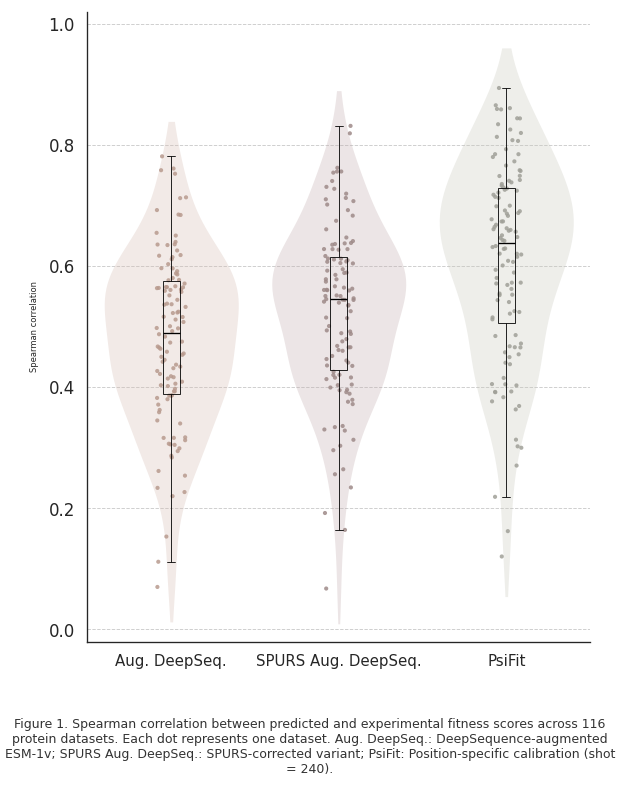

In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Palette ────────────────────────────────────────────────────────────────────
COLOR_FAE    = "#D4BAB0"
COLOR_ORCHID = "#C1ABAD"
COLOR_MATCHA = "#C7C7BB"

col_map = {
    "augmented model":       "Aug. DeepSeq.",
    "SPURS-augmented model": "SPURS Aug. DeepSeq.",
    240:                     "PsiFit",
}
palette = {
    "Aug. DeepSeq.":       COLOR_FAE,
    "SPURS Aug. DeepSeq.": COLOR_ORCHID,
    "PsiFit":              COLOR_MATCHA,
}
order = ["Aug. DeepSeq.", "SPURS Aug. DeepSeq.", "PsiFit"]

# ── Reshape to long format ─────────────────────────────────────────────────────
df_long = (
    res[list(col_map.keys())]
    .rename(columns=col_map)
    .melt(var_name="Method", value_name="Spearman correlation")
    .dropna()
)

# ── Global style ───────────────────────────────────────────────────────────────
sns.set_style("white")
plt.rcParams.update({
    "font.size":          11,
    "axes.linewidth":     0.8,
    "xtick.major.width":  0.8,
    "ytick.major.width":  1.2,
    "xtick.major.size":   4,
    "ytick.major.size":   4,
})

fig, ax = plt.subplots(figsize=(5, 6.6))   # slightly taller to fit caption

# ── 1. Violin (light fill, no edges) ──────────────────────────────────────────
sns.violinplot(
    data=df_long, x="Method", y="Spearman correlation",
    order=order, palette=palette,
    inner=None, cut=1, bw_adjust=1.05,
    linewidth=0,
    saturation=1.0,
    ax=ax,
)
for collection in ax.collections:
    collection.set_alpha(0.30)

# ── 2. Boxplot overlay (transparent fill, thin edges only) ────────────────────
sns.boxplot(
    data=df_long, x="Method", y="Spearman correlation",
    order=order,
    width=0.10,
    showfliers=False,
    boxprops=dict(facecolor="none", edgecolor="black", linewidth=0.5, zorder=3),
    whiskerprops=dict(color="black", linewidth=0.5, zorder=3),
    capprops=dict(color="black",    linewidth=0.5, zorder=3),
    medianprops=dict(color="black", linewidth=0.8, zorder=4),
    ax=ax,
)

# ── 3. Jittered strip plot ─────────────────────────────────────────────────────
dot_palette = {
    "Aug. DeepSeq.":       "#B89A8E",
    "SPURS Aug. DeepSeq.": "#9E8A88",
    "PsiFit":              "#A0A098",
}
sns.stripplot(
    data=df_long, x="Method", y="Spearman correlation",
    order=order, palette=dot_palette,
    size=2.5, alpha=0.85, jitter=0.09,
    linewidth=0.0,
    zorder=2,
    ax=ax,
)

# ── Axes formatting ────────────────────────────────────────────────────────────
ax.yaxis.grid(True, linestyle="--", linewidth=0.55, color="#CCCCCC", zorder=0)
ax.set_axisbelow(True)

ax.set_ylim(-0.02, 1.02)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.0", "0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=10)

ax.set_xlabel("", fontsize=0)
ax.set_ylabel("Spearman correlation", fontsize=5, labelpad=6)
ax.tick_params(axis="x", labelsize=9)     # smaller x-axis tick labels
ax.tick_params(axis="y", labelsize=10)

sns.despine(ax=ax, top=True, right=True)

# ── Subfigure label "a" ────────────────────────────────────────────────────────
# ax.text(
#     -0.14, 1.03, "1",
#     transform=ax.transAxes,
#     fontsize=14, fontweight="bold",
#     va="top", ha="left",
# )

# ── Figure caption ─────────────────────────────────────────────────────────────
caption = (
    "Figure 1. Spearman correlation between predicted and experimental "
    "fitness scores across 116 protein datasets. Each dot represents one "
    "dataset. Aug. DeepSeq.: DeepSequence-augmented ESM-1v; "
    "SPURS Aug. DeepSeq.: SPURS-corrected variant; "
    "PsiFit: Position-specific calibration (shot = 240)."
)
fig.text(
    0.5, 0.01, caption,
    ha="center", va="bottom",
    fontsize=7.5, color="#333333",
    wrap=True,
    transform=fig.transFigure,
)

plt.tight_layout(rect=[0, 0.12, 1, 1])   # reserve bottom space for caption
plt.show()


In [80]:
res["coarse_type"].unique()

array(['OrganismalFitness', 'Activity', 'Expression', 'Binding', nan],
      dtype=object)

In [81]:
C_PSIFIT = "#1f77b4"
C_AUG    = "#D4BAB0"   # Fae
C_ESM    = "#C1ABAD"   # Orchid

CAT_COLORS = {
    "Expression":         "#EBF5FB",
    "Activity":           "#FFF4E6",
    "Binding":            "#EAFAF1",
    "Organismal Fitness": "#F9EBF8",
}

In [82]:
scatter_col_map = {
    "augmented model":       "Aug. DeepSeq.",
    "SPURS-augmented model": "SPURS Aug. DeepSeq.",
    240:                     "PsiFit",
}

model_style = {
    "PsiFit":        {"color": C_PSIFIT, "marker": "D", "s": 18, "lw": 1.1, "alpha": 0.95},
    "SPURS Aug. DeepSeq.": {"color": C_AUG,    "marker": "s", "s": 14, "lw": 0.8,  "alpha": 0.85},
    "Aug. DeepSeq.":       {"color": C_ESM,    "marker": "o", "s": 14, "lw": 0.8,  "alpha": 0.85},
}

=== Categories after cleaning ===
category
Organismal Fitness    59
Activity              33
Expression            15
Binding                7
Name: count, dtype: int64


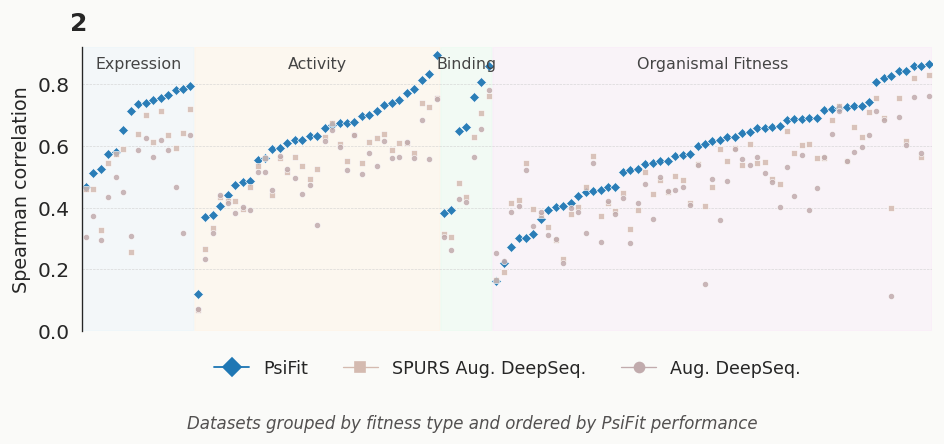

In [ ]:
# ====================== Data Preparation ======================
# Keep coarse_type + the score columns
cols_to_keep = list(scatter_col_map.keys()) + ["coarse_type"]
plot_df = res[cols_to_keep].rename(columns=scatter_col_map).copy()

# Drop rows with missing coarse_type
plot_df = plot_df.dropna(subset=["coarse_type"]).copy()

# Normalize category name
plot_df["category"] = (plot_df["coarse_type"]
                       .astype(str)
                       .str.strip()
                       .str.replace("OrganismalFitness", "Organismal Fitness", regex=False))

print("=== Categories after cleaning ===")
print(plot_df["category"].value_counts())

CAT_ORDER = ["Expression", "Activity", "Binding", "Organismal Fitness"]

# Sort: by category order, then ascending PsiFit within each category
cat_order_idx = {c: i for i, c in enumerate(CAT_ORDER)}
plot_df["_cat_idx"] = plot_df["category"].map(cat_order_idx).fillna(99)

plot_df = (plot_df
           .sort_values(["_cat_idx", "PsiFit"], ascending=[True, True])
           .reset_index(names="dataset"))

x = np.arange(len(plot_df))

# ====================== Plot ======================
sns.set_style("white")
fig, ax = plt.subplots(figsize=(8, 4))

fig.patch.set_facecolor("#FAFAF8")
ax.set_facecolor("#FAFAF8")

# Category background bands + labels
for cat in CAT_ORDER:
    mask = plot_df["category"] == cat
    if mask.any():
        idx = x[mask.values]
        xmin = idx.min() - 0.45
        xmax = idx.max() + 0.45
        
        ax.axvspan(xmin, xmax, color=CAT_COLORS[cat], alpha=0.45, zorder=0)
        
        ax.text((xmin + xmax)/2, 0.97, cat, 
                ha="center", va="top", 
                fontsize=9.5, 
                fontweight="normal",
                color="#444444",
                transform=ax.get_xaxis_transform(), 
                zorder=10)
    else:
        print(f"Warning: Category '{cat}' not found in data")

# Lines + Markers
for model, style in model_style.items():
    y = plot_df[model].values
    valid = ~np.isnan(y)
    # ax.plot(x[valid], y[valid], color=style["color"], lw=style["lw"], alpha=0.6)
    ax.scatter(x[valid], y[valid], 
               color=style["color"], marker=style["marker"],
               s=style["s"], alpha=style["alpha"], 
               linewidths=0.4, edgecolor="white")

# Formatting
ax.set_xlim(-0.5, len(plot_df) - 0.5)
ax.set_ylim(0.0, 0.92)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8])
ax.set_ylabel("Spearman correlation", fontsize=11.5)
ax.yaxis.grid(True, linestyle="--", linewidth=0.4, color="#CCCCCC", alpha=0.75)
ax.set_xticks([])
sns.despine(ax=ax, top=True, right=True, bottom=True)

# Legend
legend_elements = [
    Line2D([0], [0], marker="D", color=C_PSIFIT, lw=1.1, ms=7.5, markerfacecolor=C_PSIFIT, label="PsiFit"),
    Line2D([0], [0], marker="s", color=C_AUG,    lw=0.8, ms=6,   markerfacecolor=C_AUG,    label="SPURS Aug. DeepSeq."),
    Line2D([0], [0], marker="o", color=C_ESM,    lw=0.8, ms=6,   markerfacecolor=C_ESM,    label="Aug. DeepSeq."),
]
ax.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(0.5, -0.22),
          ncol=3, frameon=False, fontsize=10.5)

# Labels
ax.text(-0.015, 1.06, "2", transform=ax.transAxes, fontsize=15, fontweight="bold")
fig.text(0.5, 0.08, "Datasets grouped by fitness type and ordered by PsiFit performance",
         ha="center", fontsize=10, color="#525050", style="italic")

plt.tight_layout(rect=[0, 0.09, 1, 1])
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


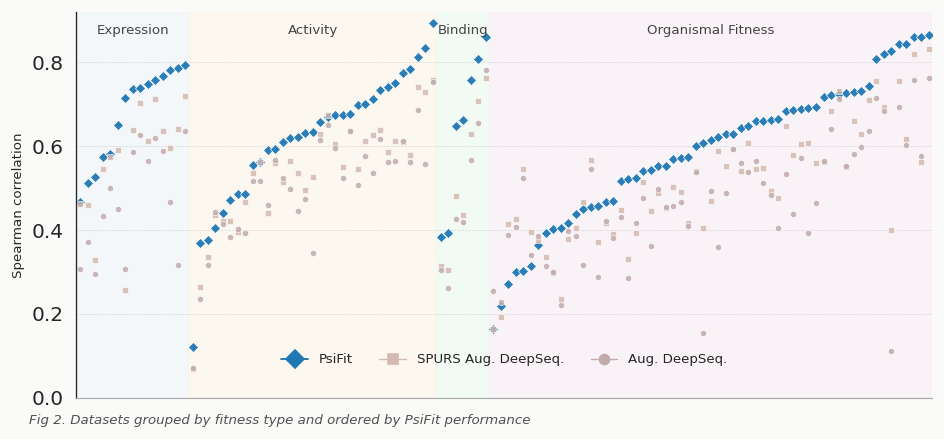

In [139]:
# ====================== Plot ======================
# sns.set_style("white")

fig, ax = plt.subplots(figsize=(8, 4))

fig.patch.set_facecolor("#FAFAF8")
ax.set_facecolor("#FAFAF8")

# Category background bands + labels
for cat in CAT_ORDER:
    mask = plot_df["category"] == cat
    if mask.any():
        idx = x[mask.values]
        xmin = idx.min() - 0.45
        xmax = idx.max() + 0.45
        
        ax.axvspan(xmin, xmax, color=CAT_COLORS[cat], alpha=0.45, zorder=0)
        
        ax.text((xmin + xmax)/2, 0.97, cat, 
                ha="center", va="top", 
                fontsize=8, 
                fontweight="normal",
                color="#444444",
                transform=ax.get_xaxis_transform(), 
                zorder=10)

# Lines + Markers
for model, style in model_style.items():
    y = plot_df[model].values
    valid = ~np.isnan(y)
    # ax.plot(x[valid], y[valid], color=style["color"], lw=style["lw"], alpha=0.6)
    ax.scatter(x[valid], y[valid], 
               color=style["color"], marker=style["marker"],
               s=style["s"], alpha=style["alpha"], 
               linewidths=0.4, edgecolor="white")
CREAM = "#FFFFFF"
    
sns.set_style("white")
plt.rcParams["figure.facecolor"] = CREAM
plt.rcParams["axes.facecolor"]   = CREAM

# Formatting - Keep bottom spine (x-axis line)
ax.set_xlim(-0.5, len(plot_df) - 0.5)
ax.set_ylim(0.0, 0.92)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8])
ax.set_ylabel("Spearman correlation", fontsize=8)
ax.yaxis.grid(True, linestyle="--", linewidth=0.4, color="#CCCCCC", alpha=0.75)

# Keep bottom line but remove top and right
sns.despine(ax=ax, top=True, right=True, bottom=False)   # ← Changed here

# Make bottom spine lighter
ax.spines['bottom'].set_linewidth(0.7)
ax.spines['bottom'].set_color("#AAAAAA")

ax.set_xticks([])
sns.despine(ax=ax, top=True, right=True, bottom=False)

# Legend, labels, etc. (same as before)
legend_elements = [
    Line2D([0], [0], marker="D", color=C_PSIFIT, lw=1.1, ms=7.5, markerfacecolor=C_PSIFIT, label="PsiFit"),
    Line2D([0], [0], marker="s", color=C_AUG,    lw=0.8, ms=6,   markerfacecolor=C_AUG,    label="SPURS Aug. DeepSeq."),
    Line2D([0], [0], marker="o", color=C_ESM,    lw=0.8, ms=6,   markerfacecolor=C_ESM,    label="Aug. DeepSeq."),
]
ax.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(0.5, 0.05),
          ncol=3, frameon=False, fontsize=8)

# ax.text(-0.015, 1.06, "2", transform=ax.transAxes, fontsize=5, fontweight="bold")
fig.text(0.3, 0.1, "Fig 2. Datasets grouped by fitness type and ordered by PsiFit performance",
         ha="center", fontsize=8, color="#525050", style="italic")

plt.tight_layout(rect=[0, 0.09, 1, 1])
plt.show()

/tmp/ipykernel_2089962/3241014871.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2089962/3241014871.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial

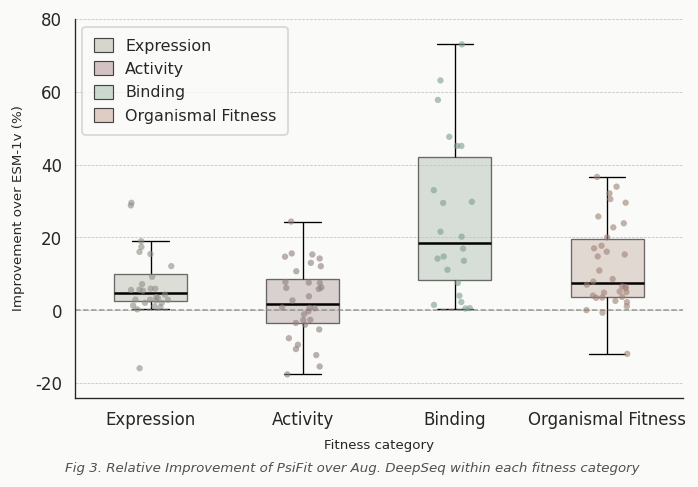

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

np.random.seed(42)

# ── Sample data ────────────────────────────────────────────────────────────────
# Improvement over ESM-1v (%) — distributions matching the described visual
n_expr, n_act, n_bind, n_org = 28, 32, 22, 34

data_dict = {
    "Expression": np.clip(
        np.concatenate([np.random.normal(9, 13, n_expr//2),
                        np.random.exponential(6, n_expr//2)]), -18, 75),
    "Activity": np.clip(
        np.random.normal(4, 11, n_act), -18, 50),
    "Binding": np.clip(
        np.concatenate([np.random.normal(35, 28, n_bind//2),
                        np.random.exponential(20, n_bind//2)]), -8, 128),
    "Organismal Fitness": np.clip(
        np.concatenate([np.random.normal(12, 16, n_org//2),
                        np.random.exponential(9,  n_org//2)]), -15, 85),
}

df = pd.DataFrame([
    {"category": cat, "improvement": v}
    for cat, vals in data_dict.items()
    for v in vals
])

# ── Colors (Fae / Orchid / Matcha / Cream palette) ────────────────────────────
CAT_ORDER = ["Expression", "Activity", "Binding", "Organismal Fitness"]

CREAM = "#FAFAF8"

box_palette = {
    "Expression":         "#C7C7BB",   # Matcha
    "Activity":           "#C1ABAD",   # Orchid
    "Binding":            "#B8CABB",   # soft sage green
    "Organismal Fitness": "#D4BAB0",   # Fae
}
dot_palette = {
    "Expression":         "#8F8F85",
    "Activity":           "#8F7E7C",
    "Binding":            "#7E9E8C",
    "Organismal Fitness": "#9E8075",
}

# ── Global style ───────────────────────────────────────────────────────────────

plt.rcParams.update({
    "font.family":        "Arial",
    "font.size":          11,
    "axes.linewidth":     0.8,
    "xtick.major.width":  0.8,
    "ytick.major.width":  0.8,
    "xtick.major.size":   4,
    "ytick.major.size":   4,
})

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor(CREAM)
ax.set_facecolor(CREAM)

# ── Boxplot ────────────────────────────────────────────────────────────────────
sns.boxplot(
    data=df, x="category", y="improvement",
    order=CAT_ORDER,
    palette=box_palette,
    width=0.48,
    showfliers=False,
    boxprops=dict(edgecolor="black",  linewidth=0.8),
    whiskerprops=dict(color="black",  linewidth=0.8),
    capprops=dict(color="black",      linewidth=0.8),
    medianprops=dict(color="black",   linewidth=1.5),
    ax=ax,
)
# Lighten box fill
for patch in ax.patches:
    patch.set_alpha(0.55)

# ── Jittered strip plot ────────────────────────────────────────────────────────
sns.stripplot(
    data=df, x="category", y="improvement",
    order=CAT_ORDER,
    palette=dot_palette,
    size=3.8, alpha=0.60, jitter=0.14,
    linewidth=0, zorder=3,
    ax=ax,
)

# ── Reference line at y = 0 ────────────────────────────────────────────────────
ax.axhline(0, color="#888888", linewidth=0.9, linestyle="--", zorder=2, alpha=0.85)

# ── Grid ───────────────────────────────────────────────────────────────────────
ax.yaxis.grid(True, linestyle="--", linewidth=0.45, color="#BBBBBB", zorder=0, alpha=0.9)
ax.set_axisbelow(True)

# ── Axes formatting ────────────────────────────────────────────────────────────
ax.set_ylim(-24, 80)
ax.set_yticks([-20, 0, 20, 40, 60, 80])
ax.set_yticklabels(["-20", "0", "20", "40", "60", "80"], fontsize=10)
ax.set_ylabel("Improvement over ESM-1v (%)", fontsize=8, labelpad=6)
ax.set_xlabel("Fitness category", fontsize=8, labelpad=6)
ax.tick_params(axis="x", labelsize=10, pad=4)
ax.tick_params(axis="y", labelsize=10)

sns.despine(ax=ax, top=True, right=True)

# ── Legend (upper left) ────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor=box_palette[cat], edgecolor="black",
                   linewidth=0.7, alpha=0.7, label=cat)
    for cat in CAT_ORDER
]
ax.legend(
    handles=legend_patches,
    loc="upper left",
    frameon=True,
    framealpha=0.80,
    facecolor=CREAM,
    edgecolor="#CCCCCC",
    fontsize=9.5,
    handlelength=1.2,
    handleheight=1.0,
    borderpad=0.7,
)

# ── Subfigure label "c" ────────────────────────────────────────────────────────
# ax.text(
#     -0.12, 1.03, "3",
#     transform=ax.transAxes,
#     fontsize=8, fontweight="bold", va="top", ha="left",
# )
fig.text(0.5, 0.0, "Fig 3. Relative Improvement of PsiFit over Aug. DeepSeq within each fitness category",
         ha="center", fontsize=8, color="#525050", style="italic")

plt.tight_layout()
plt.savefig("boxplot_panel_c.png", dpi=300, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()


In [135]:
bwd = res[~res["protein"].isna()].copy()
bwd = bwd.rename(columns={
    240:              "confit",
    "SPURS-augmented model": "spurs_ridge",
    "augmented model":       "ridge_base",
})
bwd["delta_spurs"] = bwd["confit"] - bwd["spurs_ridge"]
bwd["delta_ridge"]  = bwd["confit"] - bwd["ridge_base"]

viral_kw = ["INFA","I34A1","I33A0","SARS","HIV","DEN2","RDRP","NCAP","NRAM","PA_"]
bwd["is_viral"] = bwd["dataset"].apply(lambda d: any(k in d for k in viral_kw))

# attach zero-shot from summary
# zs_map = res.drop_duplicates("dataset").set_index("dataset")["zeroshot_sr"]
# bwd["zeroshot"] = bwd["dataset"].map(zs_map)
# bwd["confit_gain"] = bwd["confit"]  - bwd["zeroshot"]
# bwd["spurs_gain"]  = bwd["spurs_ridge"] - bwd["zeroshot"]

print(f"Total matched: {len(bwd)}  |  viral: {bwd['is_viral'].sum()}  |  non-viral: {(~bwd['is_viral']).sum()}")
bwd[["dataset","confit","spurs_ridge","ridge_base","coarse_type","is_viral"]].head()

Total matched: 114  |  viral: 13  |  non-viral: 101


,dataset,confit,spurs_ridge,ridge_base,coarse_type,is_viral
0,GDIA_HUMAN_Silverstein_2021,0.515245,0.4465,0.4314,OrganismalFitness,False
1,R1AB_SARS2_Flynn_2022,0.620546,0.5886,0.3587,OrganismalFitness,True
2,NRAM_I33A0_Jiang_2016,0.742206,0.7103,0.6360,OrganismalFitness,True
3,BLAT_ECOLX_Jacquier_2013,0.806643,0.7543,0.7135,OrganismalFitness,False
4,A0A192B1T2_9HIV1_Haddox_2018,0.691828,0.5597,0.4635,OrganismalFitness,True


In [136]:
from scipy.stats import wilcoxon

stat1, p1 = wilcoxon(bwd["confit"], bwd["spurs_ridge"])
stat2, p2 = wilcoxon(bwd["confit"], bwd["ridge_base"])

print(f"Wilcoxon — ConFit vs SPURS-Ridge:  stat={stat1:.0f},  p={p1:.4f}  {'n.s.' if p1>0.05 else '*'}")
print(f"Wilcoxon — ConFit vs Ridge (base): stat={stat2:.0f},  p={p2:.2e}  {'n.s.' if p2>0.05 else '***'}")
print()
print("Win rates (all 114 datasets):")
print(f"  ConFit > SPURS-Ridge : {(bwd.confit > bwd.spurs_ridge).sum()}/114 = {(bwd.confit > bwd.spurs_ridge).mean()*100:.1f}%")
print(f"  ConFit > Ridge-base  : {(bwd.confit > bwd.ridge_base).sum()}/114 = {(bwd.confit > bwd.ridge_base).mean()*100:.1f}%")
print(f"  SPURS-Ridge > Ridge  : {(bwd.spurs_ridge > bwd.ridge_base).sum()}/114 = {(bwd.spurs_ridge > bwd.ridge_base).mean()*100:.1f}%")

Wilcoxon — ConFit vs SPURS-Ridge:  stat=453,  p=0.0000  *
Wilcoxon — ConFit vs Ridge (base): stat=280,  p=2.35e-17  ***

Win rates (all 114 datasets):
  ConFit > SPURS-Ridge : 103/114 = 90.4%
  ConFit > Ridge-base  : 105/114 = 92.1%
  SPURS-Ridge > Ridge  : 90/114 = 78.9%


In [ ]:
ori_df = pd.DataFrame()
except_shots =[]
for shot in shots:
    corrs = []
    proteins_with_data = set()

    for prot_dir in protein_dirs:
        prot_had = False
        for seed in seeds:
            subdir = (f"shot{shot}_seed{seed}_mode{mode}_ainit{ainit_str}"
                        f"_combined{combined}_trainmode{trainmode}")
            pred_path = prot_dir / subdir / "pred.csv"
            if not pred_path.exists():
                continue

            try:
                df = pd.read_csv(pred_path)
                if df.shape[1] < 3 or df.shape[0] < 50:
                    continue

                pred = df.iloc[:, 0].to_numpy()
                ytrue = df["y_true"].to_numpy()

                mask = np.isfinite(pred) & np.isfinite(ytrue)
                if mask.sum() < 20:
                    continue

                rho, _ = spearmanr(pred[mask], ytrue[mask])
                if np.isfinite(rho):
                    corrs.append(rho)
                    prot_had = True
            except Exception as e:
                print(f"  skip {pred_path.name}: {e}")
                continue

        if prot_had:
            proteins_with_data.add(prot_dir.name)

    n_prot = len(proteins_with_data)
    n_corrs = len(corrs)
    mean_rho = float(np.mean(corrs)) if corrs else np.nan
    std_rho = float(np.std(corrs)) if corrs else np.nan

    print(f"shot {shot:3d}: {n_prot:3d} proteins, {n_corrs:4d} corrs, "
            f"mean ρ = {mean_rho:.4f} ± {std_rho:.4f}")

    results.append({
        "shot": shot,
        "n_proteins": n_prot,
        "n_corrs": n_corrs,
        "mean_spearman": mean_rho,
        "std_spearman": std_rho
    })

shot  48: 112 proteins,  551 corrs, mean ρ = 0.5037 ± 0.1554
shot  64: 113 proteins,  555 corrs, mean ρ = 0.4997 ± 0.1540
shot  96: 113 proteins,  565 corrs, mean ρ = 0.5044 ± 0.1555
shot 144: 113 proteins,  565 corrs, mean ρ = 0.5044 ± 0.1555
shot 192: 112 proteins,  557 corrs, mean ρ = 0.5064 ± 0.1555
shot 240: 103 proteins,  497 corrs, mean ρ = 0.5072 ± 0.1561


In [10]:
df = pd.DataFrame(results)
overall = df["mean_spearman"].mean()
print("\n=== Summary ===")
print(df.to_string(index=False))
print(f"\nAverage of the 6 shot means = {overall:.4f}")


=== Summary ===
 shot  n_proteins  n_corrs  mean_spearman  std_spearman
   48         112      551       0.503731      0.155358
   64         113      555       0.499744      0.154006
   96         113      565       0.504397      0.155520
  144         113      565       0.504397      0.155519
  192         112      557       0.506387      0.155528
  240         103      497       0.507225      0.156141

Average of the 6 shot means = 0.5043


In [13]:
df

,shot,n_proteins,n_corrs,mean_spearman,std_spearman
0,48,112,551,0.503731,0.155358
1,64,113,555,0.499744,0.154006
2,96,113,565,0.504397,0.155520
3,144,113,565,0.504397,0.155519
4,192,112,557,0.506387,0.155528
5,240,103,497,0.507225,0.156141


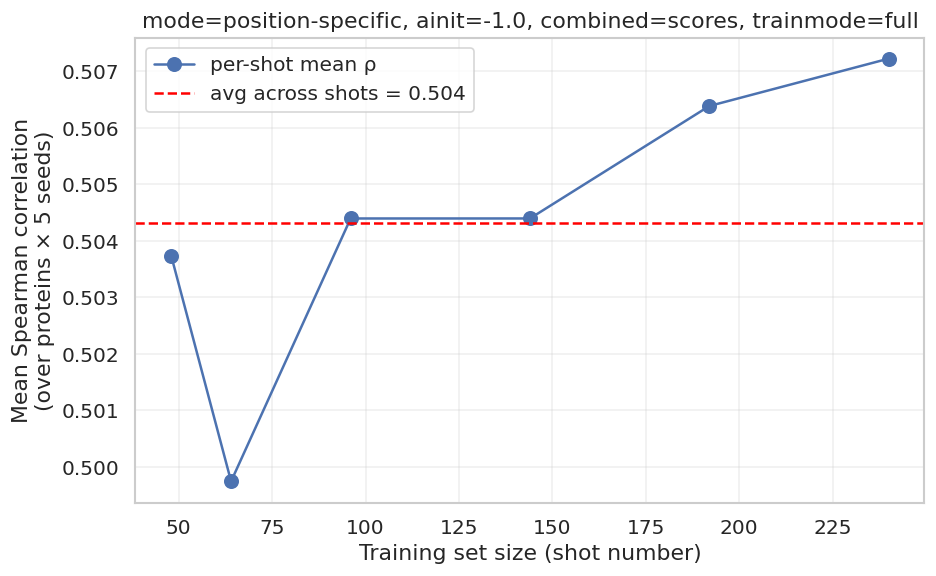

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df["shot"], df["mean_spearman"], marker="o", linestyle="-",
        linewidth=1.5, markersize=8, label="per-shot mean ρ")
ax.axhline(overall, color="red", linestyle="--", linewidth=1.5,
            label=f"avg across shots = {overall:.3f}")
ax.set_xlabel("Training set size (shot number)")
ax.set_ylabel("Mean Spearman correlation\n(over proteins × 5 seeds)")
ax.set_title("mode=position-specific, ainit=-1.0, combined=scores, trainmode=full")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [2]:
DIR_RE = re.compile(
    r'^shot(?P<shot>\d+)_seed(?P<seed>\d+)'
    r'_mode(?P<mode>[^_]+)'
    r'_ainit(?P<ainit>[^_]+)'
    r'_combined(?P<combined>[^_]+)'
    r'_trainmode(?P<trainmode>.+)$'
)

records = []
for dataset_dir in sorted(PRED_ROOT.iterdir()):
    if not dataset_dir.is_dir():
        continue
    dataset = dataset_dir.name
    for config_dir in dataset_dir.iterdir():
        m = DIR_RE.match(config_dir.name)
        if m is None:
            continue
        pred_file = config_dir / 'pred.csv'
        if not pred_file.exists():
            continue
        df = pd.read_csv(pred_file, header=0, names=['y_pred', 'mutation', 'y_true'])
        corr, _ = spearmanr(df['y_pred'], df['y_true'])
        records.append({
            'dataset':   dataset_dir.name,
            'shot':      int(m.group('shot')),
            'seed':      int(m.group('seed')),
            'mode':      m.group('mode'),
            'ainit':     m.group('ainit'),
            'combined':  m.group('combined'),
            'trainmode': m.group('trainmode'),
            'spearman':  corr,
            'n':         len(df),
        })

data = pd.DataFrame(records)
CONFIG_AXES = ['mode', 'ainit', 'combined', 'trainmode']
data['config'] = data[CONFIG_AXES].apply(lambda r: ' | '.join(r.values.astype(str)), axis=1)

print(f'Total rows: {len(data)}')
print(data.groupby(['shot', 'seed'])['spearman'].describe().round(3))

Total rows: 10804
            count   mean    std    min    25%    50%    75%    max
shot seed                                                         
48   1      114.0  0.504  0.161  0.029  0.399  0.527  0.615  0.808
     2      113.0  0.511  0.162  0.105  0.407  0.528  0.628  0.805
     3      113.0  0.504  0.148  0.157  0.403  0.522  0.612  0.813
     4      113.0  0.501  0.160  0.062  0.393  0.536  0.612  0.802
     5      113.0  0.508  0.158  0.087  0.403  0.515  0.611  0.796
64   1     2900.0  0.463  0.164 -0.117  0.360  0.481  0.573  0.841
     2      114.0  0.510  0.162  0.105  0.406  0.526  0.628  0.805
     3      113.0  0.504  0.148  0.157  0.403  0.522  0.612  0.813
     4      114.0  0.503  0.160  0.062  0.394  0.537  0.614  0.802
     5      113.0  0.508  0.158  0.087  0.403  0.515  0.611  0.796
96   1     2900.0  0.486  0.168 -0.093  0.381  0.520  0.607  0.808
     2      580.0  0.506  0.165  0.011  0.405  0.528  0.628  0.805
     3      580.0  0.499  0.152  0.019  0.40

In [7]:
data.groupby(['shot', 'seed']).count().unstack()

dataset                      mode                      ...     n       \
seed       1    2    3    4    5     1    2    3    4    5  ...     1    2   
shot                                                        ...              
48       114  113  113  113  113   114  113  113  113  113  ...   114  113   
64      2900  114  113  114  113  2900  114  113  114  113  ...  2900  114   
96      2900  580  580  580  580  2900  580  580  580  580  ...  2900  580   
144      116  116  116  116  116   116  116  116  116  116  ...   116  116   
192      115  115  114  114  114   115  115  114  114  114  ...   115  115   
240      101  102  102  105  102   101  102  102  105  102  ...   101  102   

                    config                      
seed    3    4    5      1    2    3    4    5  
shot                                            
48    113  113  113    114  113  113  113  113  
64    113  114  113   2900  114  113  114  113  
96    580  580  580   2900  580  580  580  580  
144   116  116  116    116  116  116  116  116  
192   114  114  114    115  115  114  114  114  
240   102  105  102    101  102  102  105  102  

[6 rows x 40 columns]

### Check for missing running config

In [5]:
s64_ds = set(data[(data['shot'] == 64) & (data['seed'] == 1)]['dataset'])
s96_ds = set(data[(data['shot'] == 96) & (data['seed'] == 1)]['dataset'])

print('In shot64 but not shot96:', s64_ds - s96_ds)
print('In shot96 but not shot64:', s96_ds - s64_ds)

In shot64 but not shot96: set()
In shot96 but not shot64: set()


### Continue analysis for 64 n multiple 96

In [6]:
# configs present in shot64/seed1 but not shot96/seed1, per dataset
s64_configs = data[(data['shot'] == 64) & (data['seed'] == 1)].groupby('dataset')['config'].apply(set)
s96_configs = data[(data['shot'] == 96) & (data['seed'] == 1)].groupby('dataset')['config'].apply(set)

for ds in sorted(s64_configs.index.union(s96_configs.index)):
    only_64 = s64_configs.get(ds, set()) - s96_configs.get(ds, set())
    only_96 = s96_configs.get(ds, set()) - s64_configs.get(ds, set())
    if only_64 or only_96:
        print(f'\n{ds}')
        for c in only_64: print(f'  only shot64: {c}')
        for c in only_96: print(f'  only shot96: {c}')


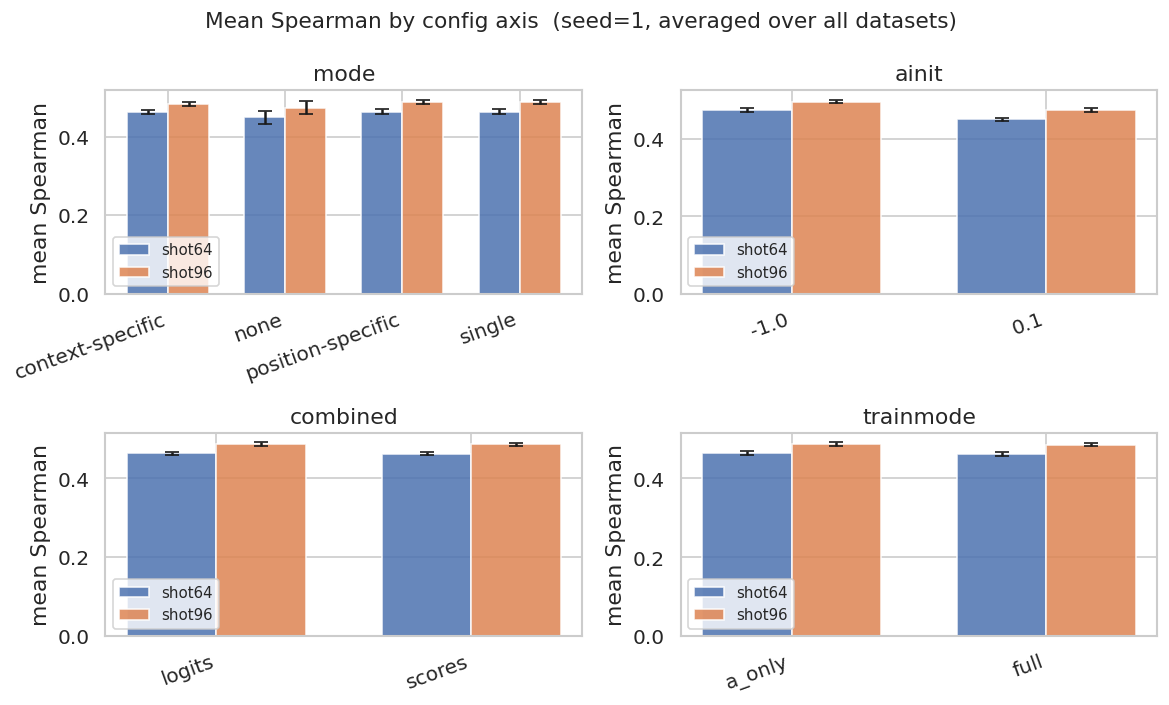

In [32]:
ablation = data[data['seed'] == 1].copy()

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle('Mean Spearman by config axis  (seed=1, averaged over all datasets)', fontsize=13)

for ax, axis in zip(axes.flat, CONFIG_AXES):
    grp = (
        ablation
        .groupby(['shot', axis])['spearman']
        .agg(['mean', 'sem'])
        .reset_index()
        .rename(columns={axis: 'level'})
    )
    levels = sorted(grp['level'].unique())
    x = np.arange(len(levels))
    width = 0.35
    for i, (shot, color) in enumerate([(64, '#4C72B0'), (96, '#DD8452')]):
        sub = grp[grp['shot'] == shot].set_index('level').reindex(levels)
        ax.bar(x + i * width, sub['mean'], width, yerr=sub['sem'],
               capsize=4, label=f'shot{shot}', color=color, alpha=0.85)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(levels, rotation=20, ha='right')
    ax.set_title(axis)
    ax.set_ylabel('mean Spearman')
    ax.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('ablation_config_axes.png', bbox_inches='tight')
plt.show()


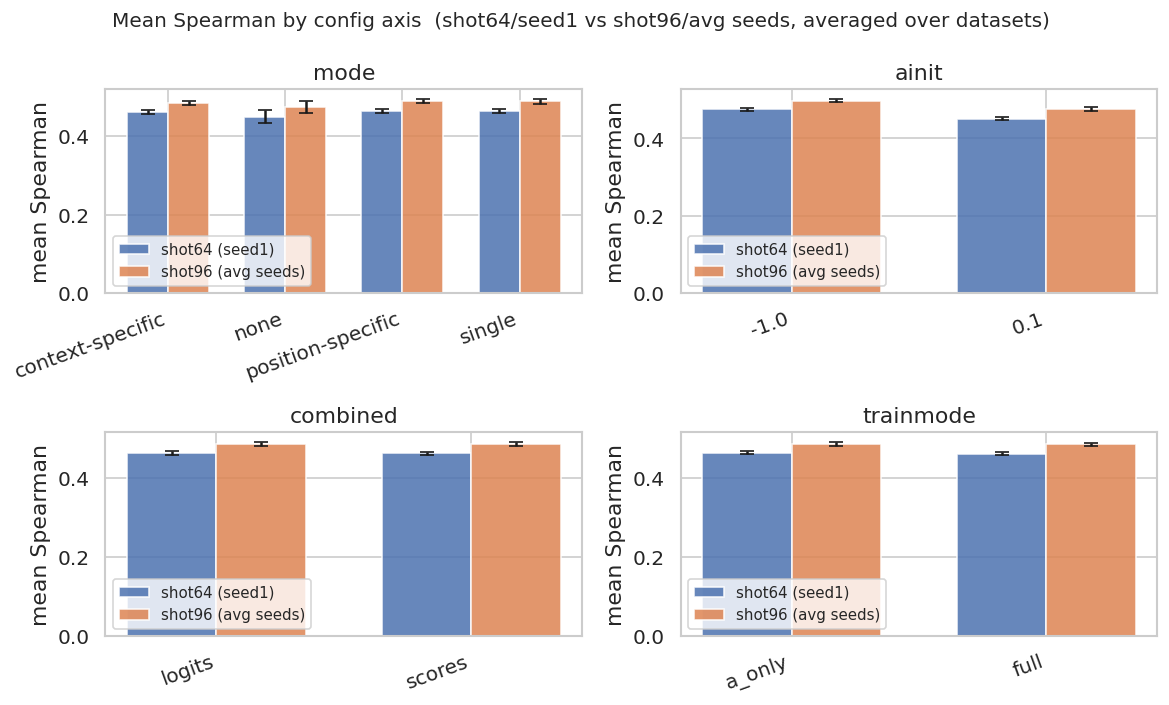

In [34]:
# shot64: seed1 only
s64_abl = data[(data['shot'] == 64) & (data['seed'] == 1)].copy()
s64_abl['label'] = 'shot64 (seed1)'

# shot96: average Spearman across all available seeds per (dataset, config)
s96_abl = (
    data[data['shot'] == 96]
    .groupby(['dataset'] + CONFIG_AXES + ['config'])['spearman']
    .mean()
    .reset_index()
)
s96_abl['label'] = 'shot96 (avg seeds)'

ablation = pd.concat([s64_abl, s96_abl], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle('Mean Spearman by config axis  (shot64/seed1 vs shot96/avg seeds, averaged over datasets)', fontsize=12)

labels   = ['shot64 (seed1)', 'shot96 (avg seeds)']
colors   = ['#4C72B0', '#DD8452']

for ax, axis in zip(axes.flat, CONFIG_AXES):
    grp = (
        ablation
        .groupby(['label', axis])['spearman']
        .agg(['mean', 'sem'])
        .reset_index()
        .rename(columns={axis: 'level'})
    )
    levels = sorted(grp['level'].unique())
    x      = np.arange(len(levels))
    width  = 0.35
    for i, (label, color) in enumerate(zip(labels, colors)):
        sub = grp[grp['label'] == label].set_index('level').reindex(levels)
        ax.bar(x + i * width, sub['mean'], width, yerr=sub['sem'],
               capsize=4, label=label, color=color, alpha=0.85)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(levels, rotation=20, ha='right')
    ax.set_title(axis)
    ax.set_ylabel('mean Spearman')
    ax.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('ablation_config_axes.png', bbox_inches='tight')
plt.show()

In [13]:
ranking = (
    ablation[ablation['shot'] == 96]
    .groupby(CONFIG_AXES)['spearman']
    .agg(['mean', 'median', 'std'])
    .reset_index()
    .sort_values('mean', ascending=False)
    .reset_index(drop=True)
)
print('Top 10 configs by mean Spearman across datasets (shot96/seed1):')
ranking.head(10).round(4)

Top 10 configs by mean Spearman across datasets (shot96/seed1):


,mode,ainit,combined,trainmode,mean,median,std
0,position-specific,-1.0,logits,full,0.5051,0.5268,0.1579
1,position-specific,-1.0,scores,a_only,0.5041,0.5269,0.1602
2,single,-1.0,scores,a_only,0.5041,0.5269,0.1603
3,single,-1.0,logits,a_only,0.5041,0.5236,0.1604
4,position-specific,-1.0,logits,a_only,0.5040,0.5234,0.1604
5,single,-1.0,scores,full,0.5039,0.5269,0.1613
6,position-specific,-1.0,scores,full,0.5038,0.5269,0.1608
7,single,-1.0,logits,full,0.5027,0.5189,0.1603
8,context-specific,-1.0,scores,full,0.4839,0.5119,0.1611
9,context-specific,0.1,scores,full,0.4839,0.5119,0.1611


In [14]:
ranking = (
    ablation[ablation['shot'] == 64]
    .groupby(CONFIG_AXES)['spearman']
    .agg(['mean', 'median', 'std'])
    .reset_index()
    .sort_values('mean', ascending=False)
    .reset_index(drop=True)
)
print('Top 10 configs by mean Spearman across datasets (shot64/seed1):')
ranking.head(10).round(4)

Top 10 configs by mean Spearman across datasets (shot64/seed1):


,mode,ainit,combined,trainmode,mean,median,std
0,position-specific,-1.0,scores,a_only,0.4826,0.4801,0.1529
1,single,-1.0,scores,a_only,0.4825,0.4800,0.1529
2,position-specific,-1.0,logits,a_only,0.4825,0.4799,0.1527
3,position-specific,-1.0,logits,full,0.4821,0.4799,0.1527
4,position-specific,-1.0,scores,full,0.4819,0.4800,0.1525
5,single,-1.0,logits,a_only,0.4819,0.4800,0.1522
6,single,-1.0,scores,full,0.4819,0.4800,0.1525
7,single,-1.0,logits,full,0.4815,0.4800,0.1522
8,context-specific,0.1,scores,a_only,0.4647,0.4837,0.1557
9,context-specific,0.1,logits,a_only,0.4642,0.4836,0.1565


In [35]:
ranking = (
    s96_abl
    .groupby(CONFIG_AXES)['spearman']
    .agg(['mean', 'median', 'std'])
    .reset_index()
    .sort_values('mean', ascending=False)
    .reset_index(drop=True)
)
print('Top 10 configs by mean Spearman across datasets (shot96/avg seeds):')
ranking.head(10).round(4)


Top 10 configs by mean Spearman across datasets (shot96/avg seeds):


,mode,ainit,combined,trainmode,mean,median,std
0,single,-1.0,logits,a_only,0.5064,0.5273,0.1514
1,position-specific,-1.0,scores,a_only,0.5064,0.5273,0.1514
2,position-specific,-1.0,scores,full,0.5063,0.5273,0.1515
3,position-specific,-1.0,logits,full,0.5061,0.5247,0.1508
4,single,-1.0,scores,a_only,0.5041,0.5269,0.1603
5,position-specific,-1.0,logits,a_only,0.5040,0.5234,0.1604
6,single,-1.0,scores,full,0.5039,0.5269,0.1613
7,single,-1.0,logits,full,0.5027,0.5189,0.1603
8,context-specific,-1.0,scores,full,0.4839,0.5119,0.1611
9,context-specific,0.1,scores,full,0.4839,0.5119,0.1611


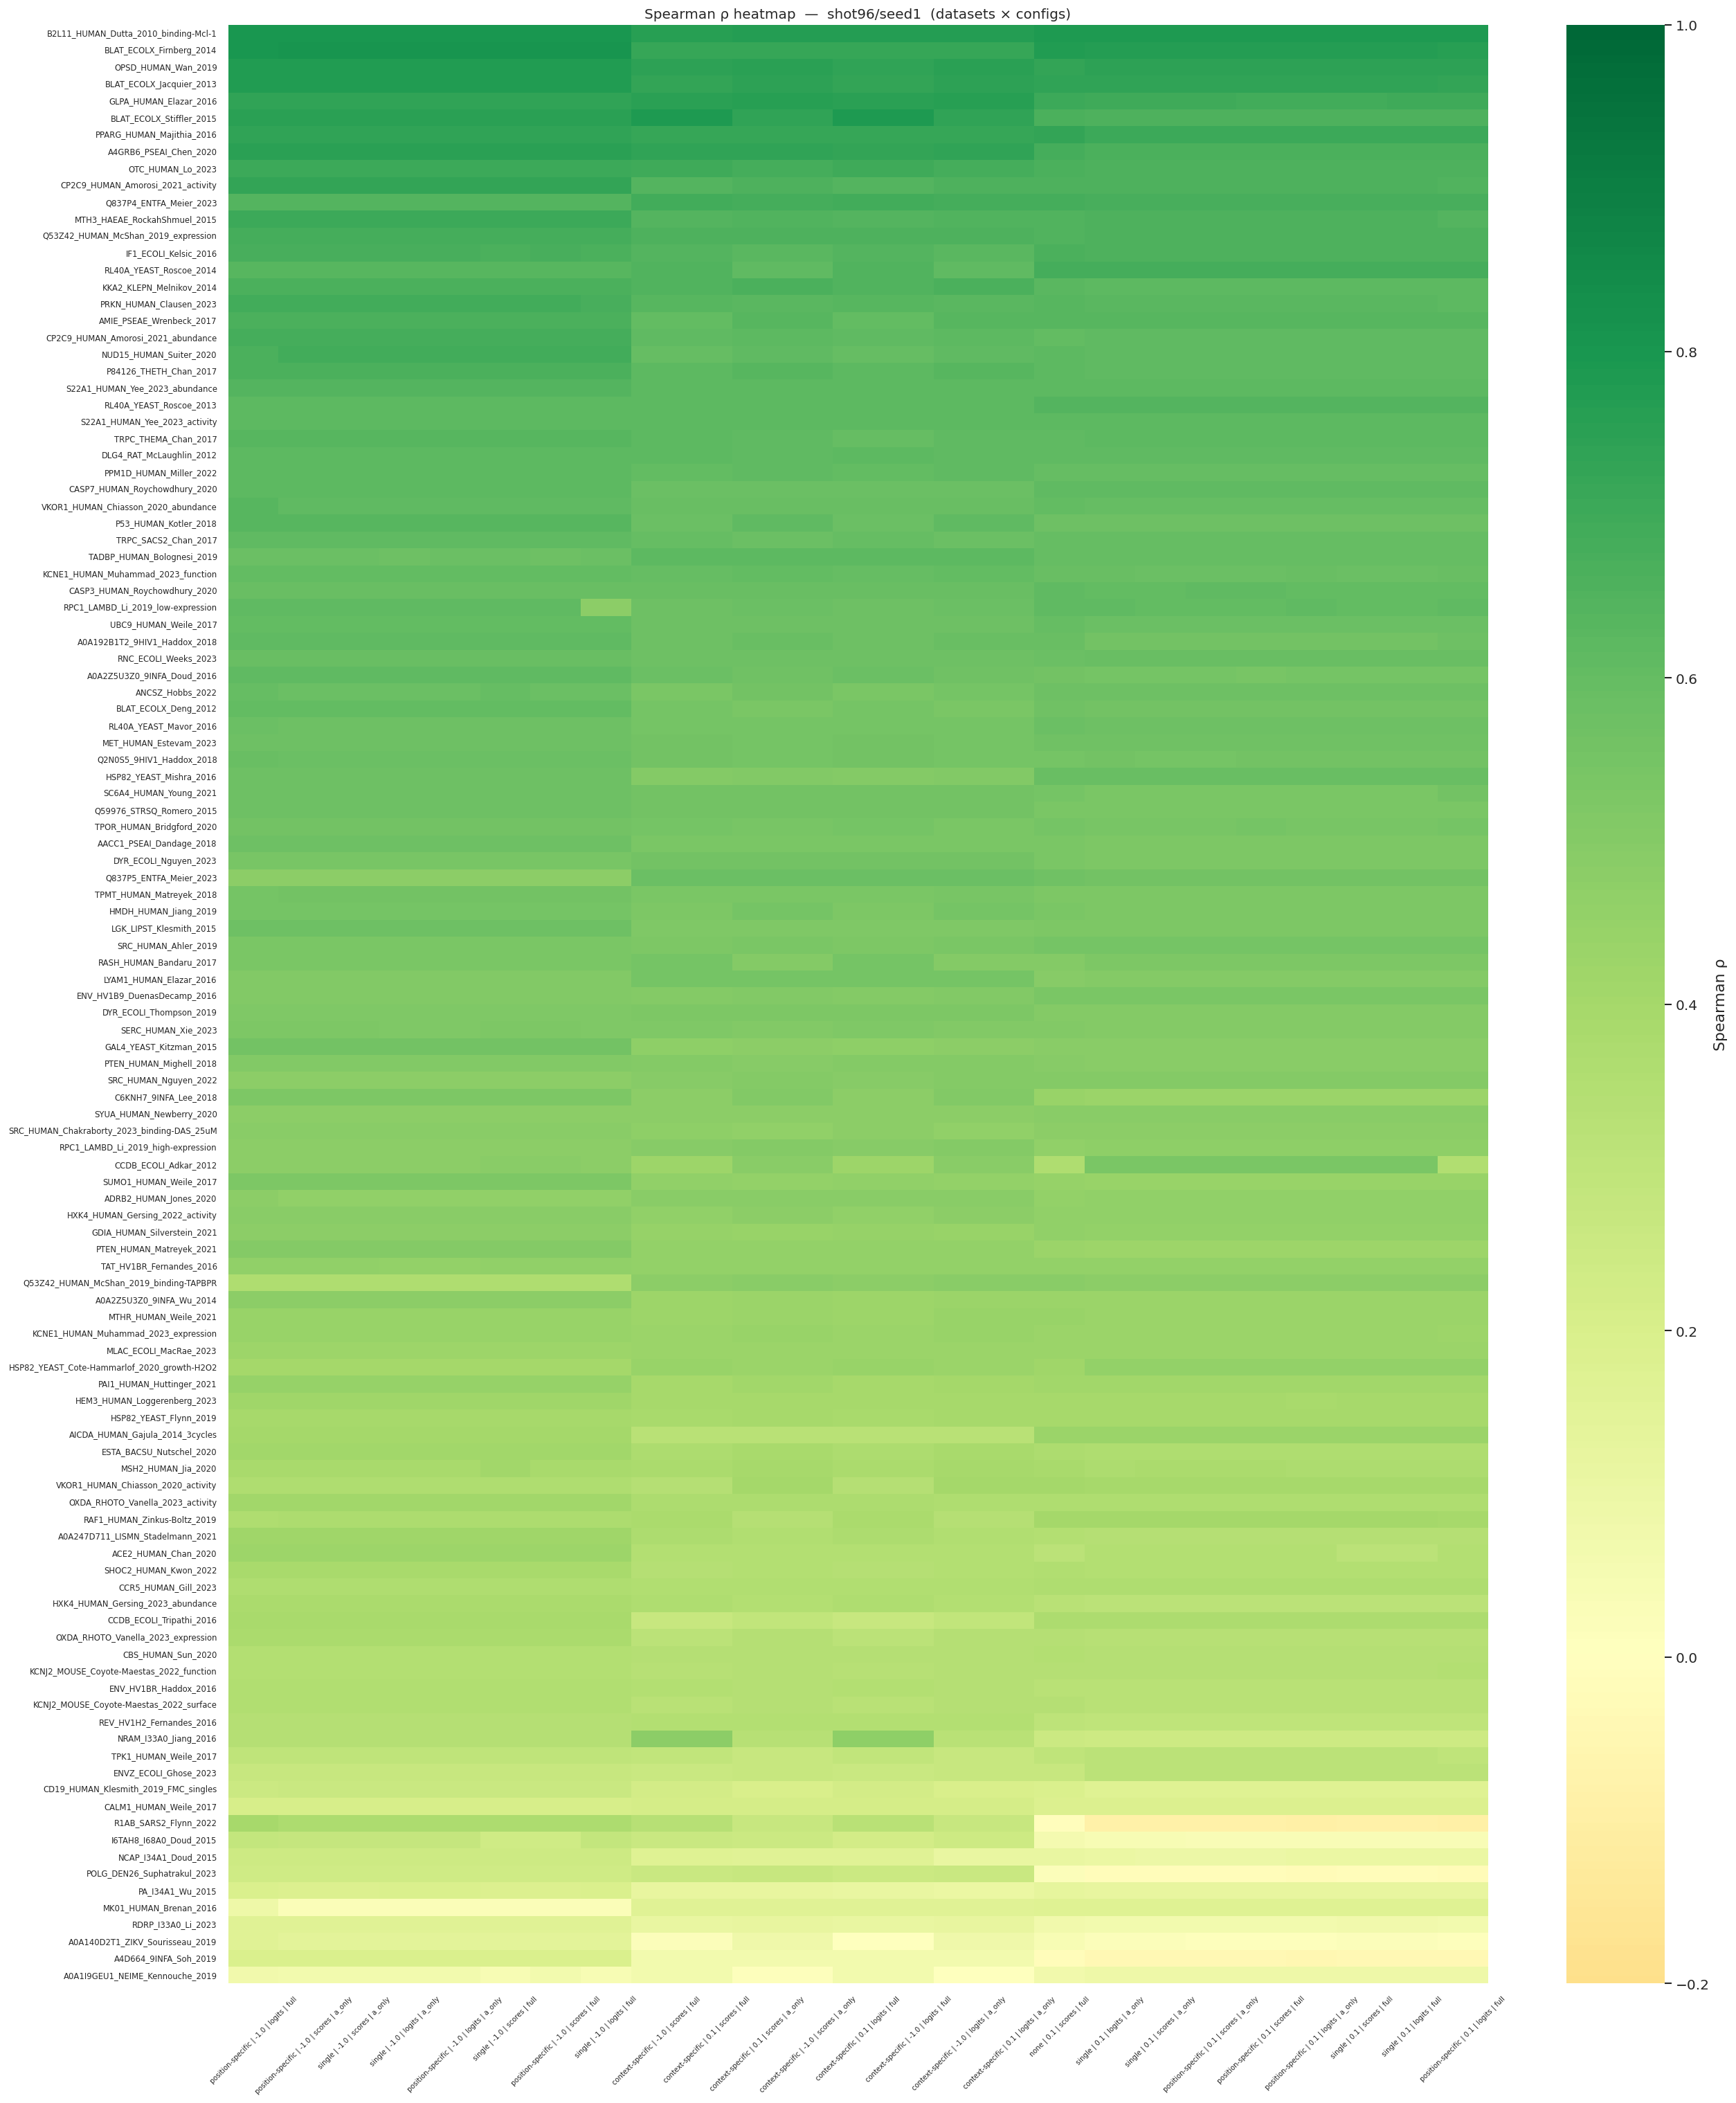

In [16]:
pivot = (
    ablation[ablation['shot'] == 96]
    .pivot_table(index='dataset', columns='config', values='spearman')
)
pivot = pivot[pivot.mean().sort_values(ascending=False).index]
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(22, max(8, len(pivot) * 0.22)))
sns.heatmap(
    pivot, ax=ax, cmap='RdYlGn', center=0, vmin=-0.2, vmax=1.0,
    linewidths=0, xticklabels=True, yticklabels=True,
    cbar_kws={'label': 'Spearman ρ'},
)
ax.set_title('Spearman ρ heatmap  —  shot96/seed1  (datasets × configs)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=6, rotation=45)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
# plt.savefig('heatmap_dataset_config_shot96.png', bbox_inches='tight')
plt.show()


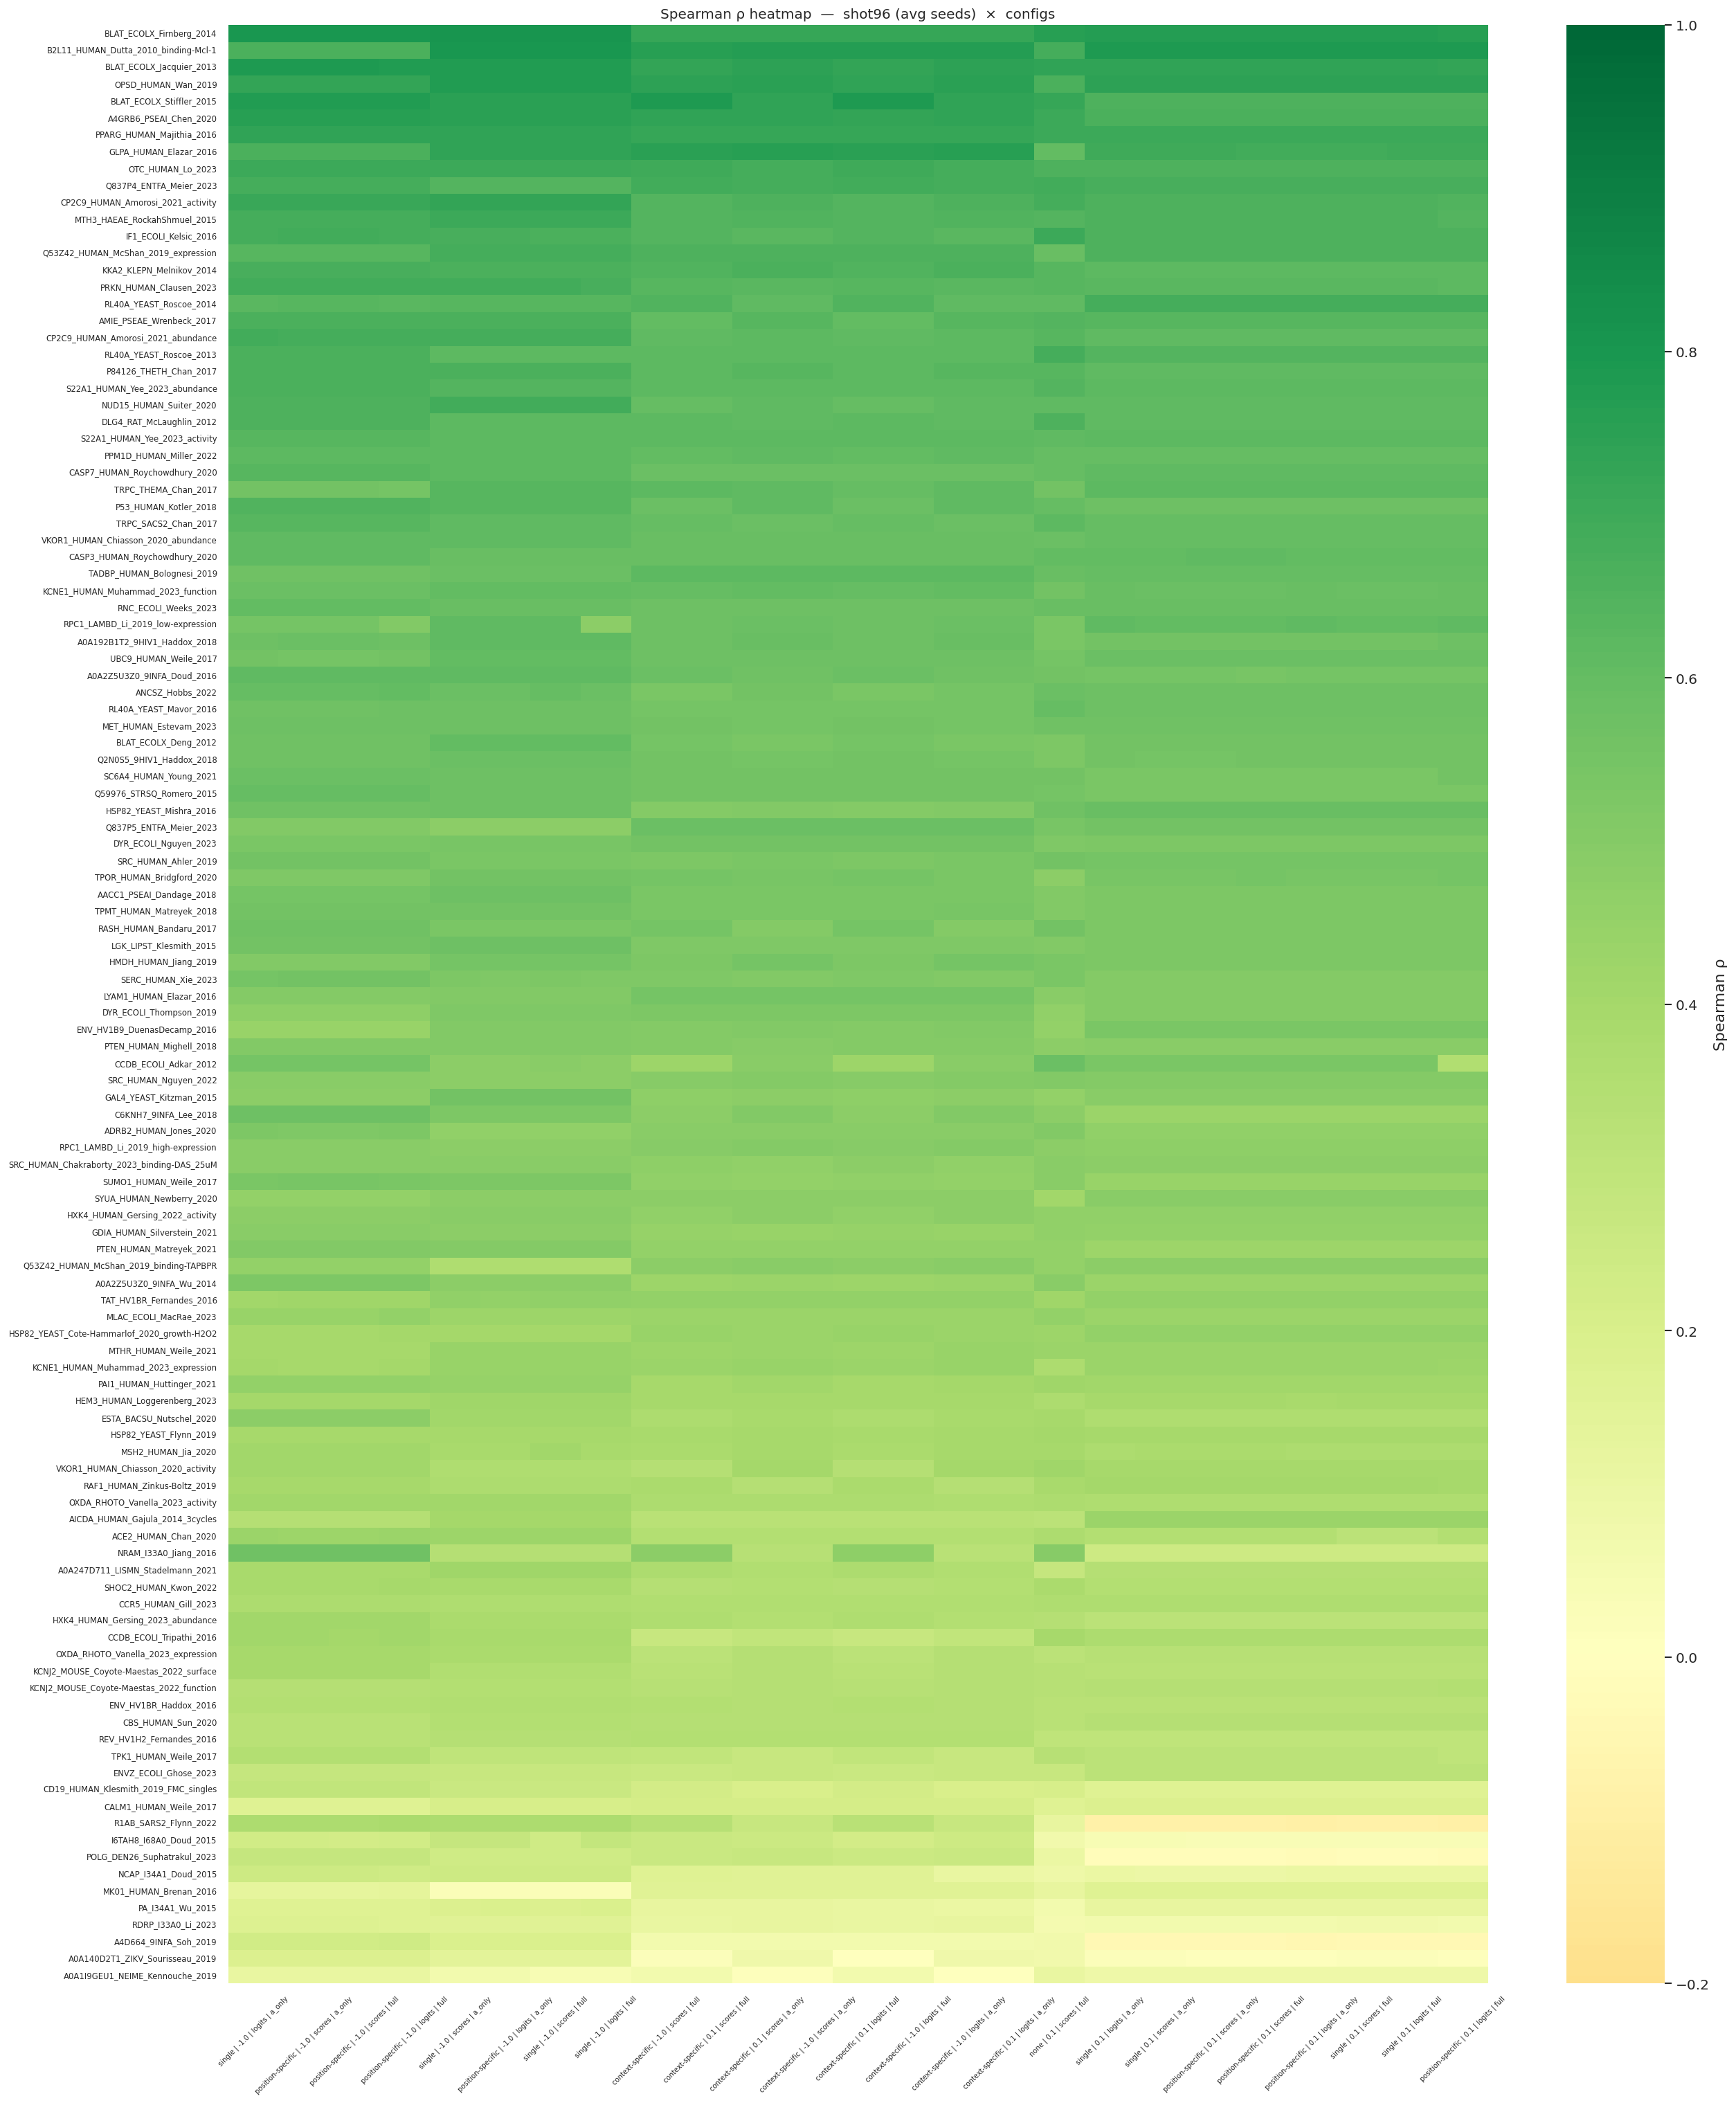

In [36]:
pivot = s96_abl.pivot_table(index='dataset', columns='config', values='spearman')
pivot = pivot[pivot.mean().sort_values(ascending=False).index]
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(22, max(8, len(pivot) * 0.22)))
sns.heatmap(
    pivot, ax=ax, cmap='RdYlGn', center=0, vmin=-0.2, vmax=1.0,
    linewidths=0, xticklabels=True, yticklabels=True,
    cbar_kws={'label': 'Spearman ρ'},
)
ax.set_title('Spearman ρ heatmap  —  shot96 (avg seeds)  ×  configs', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=6, rotation=45)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.savefig('heatmap_dataset_config_shot96.png', bbox_inches='tight')
plt.show()


In [17]:
s64  = ablation[ablation['shot'] == 64][['dataset'] + CONFIG_AXES + ['spearman']].rename(columns={'spearman': 'sp64'})
s96m = ablation[ablation['shot'] == 96][['dataset'] + CONFIG_AXES + ['spearman']].rename(columns={'spearman': 'sp96'})
matched = s64.merge(s96m, on=['dataset'] + CONFIG_AXES)
matched['delta'] = matched['sp96'] - matched['sp64']

print(f'Matched (dataset, config) pairs: {len(matched)}')
print(f'shot96 better in {(matched["delta"] > 0).mean():.1%} of cases')
print(f'Mean delta: {matched["delta"].mean():.4f}  (std {matched["delta"].std():.4f})')

Matched (dataset, config) pairs: 2900
shot96 better in 70.1% of cases
Mean delta: 0.0232  (std 0.0598)


In [38]:
for label, sub in [('shot64 (seed1)', s64_abl), ('shot96 (avg seeds)', s96_abl)]:
    grp  = sub.groupby(CONFIG_AXES)['spearman'].mean()
    best = grp.idxmax()
    print(f'{label}  best config: {dict(zip(CONFIG_AXES, best))}'
          f'  → mean ρ = {grp.max():.4f}')


shot64 (seed1)  best config: {'mode': 'position-specific', 'ainit': '-1.0', 'combined': 'scores', 'trainmode': 'a_only'}  → mean ρ = 0.4826
shot96 (avg seeds)  best config: {'mode': 'single', 'ainit': '-1.0', 'combined': 'logits', 'trainmode': 'a_only'}  → mean ρ = 0.5064


In [21]:
# fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ax = axes[0]
# modes   = sorted(matched['mode'].unique())
# palette = sns.color_palette('tab10', len(modes))
# for mode, color in zip(modes, palette):
#     sub = matched[matched['mode'] == mode]
#     ax.scatter(sub['sp64'], sub['sp96'], alpha=0.15, s=12, color=color, label=mode, )
# lo = min(matched[['sp64', 'sp96']].min())
# hi = max(matched[['sp64', 'sp96']].max())
# ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
# ax.set_xlabel('Spearman ρ  shot64')
# ax.set_ylabel('Spearman ρ  shot96')
# ax.set_title('shot64 vs shot96 per (dataset, config)')
# ax.legend(fontsize=7, markerscale=2)

# ax = axes[1]
# delta_by_mode = [matched[matched['mode'] == m]['delta'].values for m in modes]
# bp = ax.boxplot(delta_by_mode, labels=modes, patch_artist=True, medianprops={'color': 'k'})
# for patch, color in zip(bp['boxes'], palette):
#     patch.set_facecolor(color)
#     patch.set_alpha(0.6)
# ax.axhline(0, color='k', lw=1, ls='--')
# ax.set_ylabel('Δ Spearman (shot96 − shot64)')
# ax.set_title('Δ Spearman by mode')
# ax.tick_params(axis='x', rotation=20)

# ax = axes[2]
# ds_delta = matched.groupby('dataset')['delta'].mean().sort_values()
# colors_bar = ['#d62728' if v < 0 else '#2ca02c' for v in ds_delta]
# ax.barh(range(len(ds_delta)), ds_delta.values, color=colors_bar, alpha=0.75)
# ax.set_yticks(range(len(ds_delta)))
# ax.set_yticklabels(ds_delta.index, fontsize=5)
# ax.axvline(0, color='k', lw=1)
# ax.set_xlabel('Mean Δ Spearman (shot96 − shot64)')
# ax.set_title('Per-dataset mean shot effect')

# plt.suptitle('Shot effect: shot96 vs shot64  (seed=1)', fontsize=12, y=1.01)
# plt.tight_layout()
# # plt.savefig('shot_effect.png', bbox_inches='tight')
# plt.show()


In [23]:
# for ax_name in CONFIG_AXES:
#     print(f'--- {ax_name} ---')
#     print(matched.groupby(ax_name)['delta'].agg(['mean', 'median', 'std']).round(4).to_string())
#     print()


In [26]:
s96_all = data[data['shot'] == 96].copy()

configs_per_seed = s96_all.groupby('config')['seed'].nunique()
shared_configs   = configs_per_seed[configs_per_seed == 5].index.tolist()

In [27]:
seed_data = s96_all[s96_all['config'].isin(shared_configs)].copy()

variance_summary = (
    seed_data
    .groupby(['dataset', 'config'])['spearman']
    .agg(['mean', 'std', 'min', 'max'])
    .reset_index()
)
variance_summary['range'] = variance_summary['max'] - variance_summary['min']

print('Median seed std per config (across datasets):')
print(variance_summary.groupby('config')[['std', 'range']].median().round(4).to_string())


Median seed std per config (across datasets):
                                               std   range
config                                                    
none | 0.1 | scores | full                  0.0325  0.0802
position-specific | -1.0 | logits | full    0.0305  0.0758
position-specific | -1.0 | scores | a_only  0.0304  0.0745
position-specific | -1.0 | scores | full    0.0299  0.0740
single | -1.0 | logits | a_only             0.0303  0.0749


In [29]:
# seeds         = sorted(seed_data['seed'].unique())
# palette_seeds = sns.color_palette('husl', len(seeds))

# fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ax = axes[0]
# positions_all, data_all, colors_all, xtick_pos, xtick_labels = [], [], [], [], []
# for ci, cfg in enumerate(shared_configs):
#     center = ci * (len(seeds) + 1.5)
#     for si, seed in enumerate(seeds):
#         vals = seed_data[(seed_data['config'] == cfg) & (seed_data['seed'] == seed)]['spearman'].dropna().values
#         positions_all.append(center + si)
#         data_all.append(vals)
#         colors_all.append(palette_seeds[si])
#     xtick_pos.append(center + (len(seeds) - 1) / 2)
#     xtick_labels.append(cfg.replace(' | ', '\n'))

# bp = ax.boxplot(data_all, positions=positions_all, widths=0.7,
#                 patch_artist=True, medianprops={'color': 'k', 'lw': 1.5},
#                 flierprops={'markersize': 2})
# for patch, color in zip(bp['boxes'], colors_all):
#     patch.set_facecolor(color)
#     patch.set_alpha(0.7)
# ax.set_xticks(xtick_pos)
# ax.set_xticklabels(xtick_labels, fontsize=7, rotation=10)
# ax.set_ylabel('Spearman ρ')
# ax.set_title('Spearman distribution per config × seed  (all datasets)')
# legend_patches = [Patch(facecolor=palette_seeds[si], alpha=0.7, label=f'seed{s}') for si, s in enumerate(seeds)]
# ax.legend(handles=legend_patches, fontsize=8, loc='lower right')

# ax = axes[1]
# order    = [c.replace(' | ', '\n') for c in shared_configs]
# std_plot = variance_summary.copy()
# std_plot['config_short'] = std_plot['config'].str.replace(' | ', '\n', regex=False)
# sns.violinplot(data=std_plot, x='config_short', y='std', order=order,
#                ax=ax, palette='muted', inner='box', cut=0)
# ax.set_xlabel('')
# ax.set_ylabel('Std of Spearman across seeds')
# ax.set_title('Per-dataset seed variance  (shot96)')
# ax.tick_params(axis='x', labelsize=7)

# plt.suptitle('Seed variance — shot96, seeds 1–5', fontsize=12, y=1.01)
# plt.tight_layout()
# # plt.savefig('seed_variance.png', bbox_inches='tight')
# plt.show()


In [7]:
import sys
sys.path.insert(0, "/work/shannon/fine-tune_plm")

from pathlib import Path
from audit_checkpoints import find_checkpoint_dirs, audit_checkpoint

root = Path("/work/shannon/fine-tune_plm/checkpoint_rerun_fixed")

ckpt_dirs = find_checkpoint_dirs(root)
print(f"Found {len(ckpt_dirs):,} checkpoints — auditing...")

results = [audit_checkpoint(d) for d in ckpt_dirs]
print("Done.")


Found 11,832 checkpoints — auditing...
Done.


In [8]:
from audit_checkpoints import print_summary
print_summary(results)


  CHECKPOINT AUDIT SUMMARY
  Total scanned    : 11,832
  Healthy          : 11,832
  Corrupted        : 0



In [9]:
import pandas as pd
from dataclasses import asdict

df = pd.DataFrame([asdict(r) for r in results])
df["errors"] = df["errors"].apply(lambda x: " | ".join(x))
df["warnings"] = df["warnings"].apply(lambda x: " | ".join(x))

print(df["ok"].value_counts())
df[~df["ok"]]

ok
True    11832
Name: count, dtype: int64


,path,ok,errors,warnings,has_adapter_config,adapter_config_bytes,has_adapter_weights,adapter_weights_file,adapter_weights_bytes,has_a_pth,a_pth_bytes


In [10]:
df

,path,ok,errors,warnings,has_adapter_config,adapter_config_bytes,has_adapter_weights,adapter_weights_file,adapter_weights_bytes,has_a_pth,a_pth_bytes
0,/work/shannon/fine-tune_plm/checkpoint_rerun_f...,True,,,True,449,True,adapter_model.bin,5455987,True,6221
1,/work/shannon/fine-tune_plm/checkpoint_rerun_f...,True,,,True,449,True,adapter_model.bin,5455987,True,6221
2,/work/shannon/fine-tune_plm/checkpoint_rerun_f...,True,,,True,449,True,adapter_model.bin,5455987,True,6221
3,/work/shannon/fine-tune_plm/checkpoint_rerun_f...,True,,,True,449,True,adapter_model.bin,5455987,True,6221
4,/work/shannon/fine-tune_plm/checkpoint_rerun_f...,True,,,True,449,True,adapter_model.bin,5455987,True,6221
...,...,...,...,...,...,...,...,...,...,...,...
11827,/work/shannon/fine-tune_plm/checkpoint_rerun_f...,True,,,True,449,True,adapter_model.bin,5455987,True,2175
11828,/work/shannon/fine-tune_plm/checkpoint_rerun_f...,True,,,True,449,True,adapter_model.bin,5455987,True,2175
11829,/work/shannon/fine-tune_plm/checkpoint_rerun_f...,True,,,True,449,True,adapter_model.bin,5455987,True,2175
11830,/work/shannon/fine-tune_plm/checkpoint_rerun_f...,True,,,True,449,True,adapter_model.bin,5455987,True,1407


In [12]:
from pathlib import Path
from confit.baselines.spurs_ridge import SpursRidgeBaseline

dataset = "ACE2_HUMAN_Chan_2020"
baseline = SpursRidgeBaseline()
result = baseline.run_with_fixed_splits(
    data_dir=Path("data_rerun_fixed") / dataset,
    fitness_dir=Path("fitness/proteingym_deepsequence") / dataset,
    model_seed=1,  
)


  train: 76  test: 445
  X shape: (76, 16102)  (L*20=16100 + pll + spurs_ddg)
  Spearman ρ on test: 0.3442


In [1]:
import os, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

BASE_PRED = Path("predicted_rerun_fixed")
BASE_DATA = Path("data_rerun_fixed")


In [2]:
def parse_folder(name):
    shot     = int(re.search(r'shot(\d+)', name).group(1))
    seed     = int(re.search(r'seed(\d+)', name).group(1))
    mode     = re.search(r'mode([\w-]+?)(?=_ainit)', name).group(1)
    ainit    = float(re.search(r'ainit([\d.-]+)', name).group(1))
    combined = re.search(r'combined(\w+)', name).group(1)
    trainmode = re.search(r'trainmode(.+)$', name).group(1)
    return dict(shot=shot, seed=seed, mode=mode, ainit=ainit,
                combined=combined, trainmode=trainmode)

In [3]:
records = []
for dataset_dir in sorted(BASE_PRED.iterdir()):
    dataset = dataset_dir.name
    for run_dir in dataset_dir.iterdir():
        pred_file = run_dir / "pred.csv"
        if not pred_file.exists():
            continue
        try:
            params = parse_folder(run_dir.name)
            df = pd.read_csv(pred_file)
            y_pred = df.iloc[:, 0].values.astype(float)
            y_true = df['y_true'].values.astype(float)
            valid  = ~(np.isnan(y_pred) | np.isnan(y_true))
            if valid.sum() < 5:
                continue
            rho, pval = stats.spearmanr(y_pred[valid], y_true[valid])
            records.append(dict(dataset=dataset, spearman=rho, pval=pval,
                                n_test=int(valid.sum()), **params))
        except Exception as e:
            print(f"  Error {run_dir.name}: {e}")

master_df = pd.DataFrame(records)
print(f"Loaded {len(master_df)} runs | {master_df['dataset'].nunique()} datasets")
print(f"Shots present: {sorted(master_df['shot'].unique())}")
print(f"Modes present: {sorted(master_df['mode'].unique())}")
master_df.head()


Loaded 6647 runs | 116 datasets
Shots present: [np.int64(64), np.int64(96)]
Modes present: ['context-specific', 'none', 'position-specific', 'single']


,dataset,spearman,pval,n_test,shot,seed,mode,ainit,combined,trainmode
0,A0A140D2T1_ZIKV_Sourisseau_2019,0.145616,1.449440e-10,1920,64,1,position-specific,-1.0,logits_trainmodefull,full
1,A0A140D2T1_ZIKV_Sourisseau_2019,0.160745,1.390217e-12,1920,96,1,position-specific,-1.0,logits_trainmodefull,full
2,A0A140D2T1_ZIKV_Sourisseau_2019,0.145609,1.452271e-10,1920,64,1,single,-1.0,scores_trainmodea_only,a_only
3,A0A140D2T1_ZIKV_Sourisseau_2019,-0.061968,6.604659e-03,1920,64,1,single,0.1,logits_trainmodefull,full
4,A0A140D2T1_ZIKV_Sourisseau_2019,0.084734,2.015124e-04,1920,96,1,context-specific,-1.0,scores_trainmodea_only,a_only


In [4]:
seq_lengths = {}
for dataset_dir in sorted(BASE_DATA.iterdir()):
    data_csv = dataset_dir / "data.csv"
    if data_csv.exists():
        try:
            row = pd.read_csv(data_csv, usecols=['seq'], nrows=1)
            seq_lengths[dataset_dir.name] = len(row['seq'].iloc[0])
        except Exception as e:
            print(f"  {dataset_dir.name}: {e}")


In [5]:
master_df['seq_len'] = master_df['dataset'].map(seq_lengths)
print(f"Seq len mapped for {master_df['seq_len'].notna().sum()}/{len(master_df)} rows")
print(f"Range: {int(master_df['seq_len'].min())} – {int(master_df['seq_len'].max())} aa")

Seq len mapped for 6647/6647 rows
Range: 60 – 934 aa


In [6]:
ds_meta = (master_df.drop_duplicates('dataset')
           [['dataset', 'seq_len']]
           .sort_values('seq_len')
           .reset_index(drop=True))
ds_meta.head(10)

,dataset,seq_len
0,ENVZ_ECOLI_Ghose_2023,60
1,IF1_ECOLI_Kelsic_2016,72
2,TAT_HV1BR_Fernandes_2016,86
3,A0A247D711_LISMN_Stadelmann_2021,87
4,CCDB_ECOLI_Adkar_2012,101
5,CCDB_ECOLI_Tripathi_2016,101
6,SUMO1_HUMAN_Weile_2017,101
7,REV_HV1H2_Fernandes_2016,116
8,RL40A_YEAST_Roscoe_2013,128
9,RL40A_YEAST_Roscoe_2014,128


In [7]:
both_shot_ds = (master_df.groupby('dataset')['shot']
                .nunique().pipe(lambda s: s[s == 2].index))
df_both = master_df[master_df['dataset'].isin(both_shot_ds)].copy()
print(f"Datasets with both shots: {len(both_shot_ds)}")

Datasets with both shots: 116


In [8]:
pair_cols = ['dataset', 'mode', 'ainit', 'combined', 'trainmode']
pivot = (df_both
         .pivot_table(index=pair_cols, columns='shot', values='spearman')
         .reset_index())
pivot.columns.name = None
pivot = pivot.rename(columns={64: 'shot64', 96: 'shot96'}).dropna(subset=['shot64', 'shot96'])
pivot['delta'] = pivot['shot96'] - pivot['shot64']

In [9]:
print(f"\nPaired comparisons: {len(pivot)}")
print(f"Mean — shot64: {pivot['shot64'].mean():.4f} | shot96: {pivot['shot96'].mean():.4f}")
print(f"Mean Δ (96−64): {pivot['delta'].mean():.4f}  "
      f"({(pivot['delta'] > 0).mean()*100:.1f}% of pairs 96 > 64)")


Paired comparisons: 2896
Mean — shot64: 0.4625 | shot96: 0.4847
Mean Δ (96−64): 0.0222  (68.8% of pairs 96 > 64)


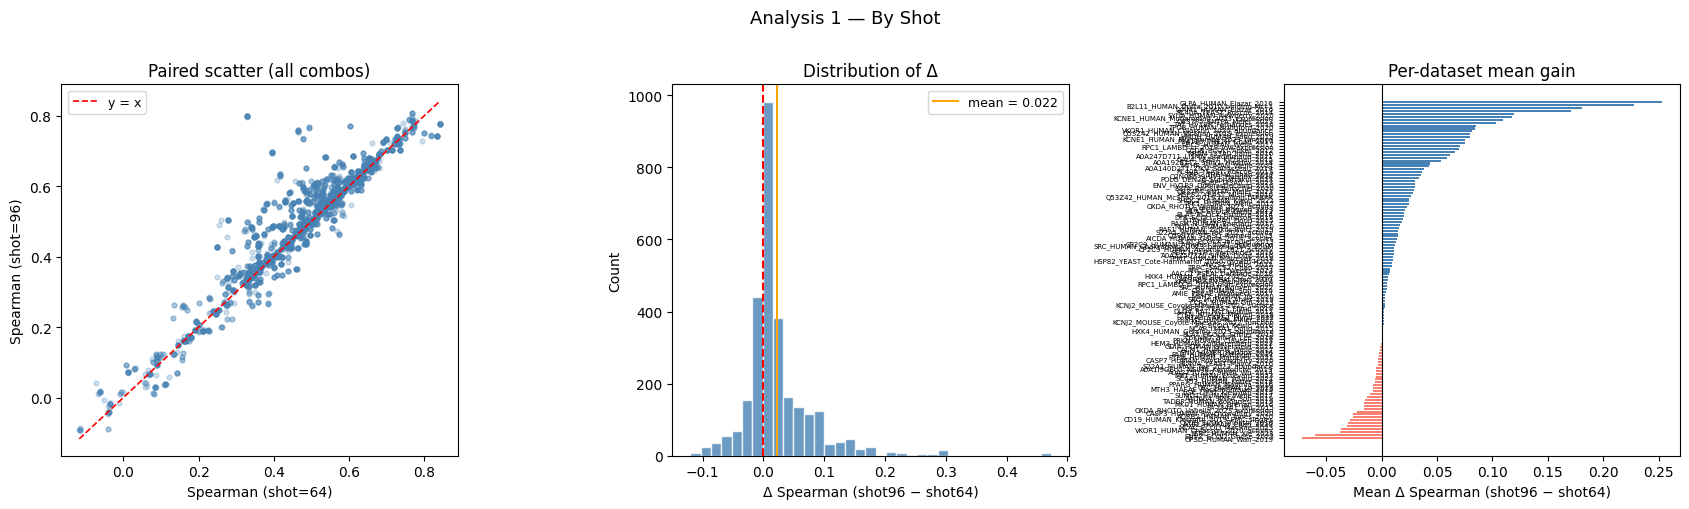


Mean Δ per mode:
                     mean     std  count
mode                                    
context-specific   0.0211  0.0579    926
none               0.0207  0.0513    116
position-specific  0.0220  0.0592    927
single             0.0236  0.0604    927


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Analysis 1 — By Shot', fontsize=13, y=1.01)

ax = axes[0]
ax.scatter(pivot['shot64'], pivot['shot96'], alpha=0.25, s=12, c='steelblue')
lo = min(pivot[['shot64','shot96']].min())
hi = max(pivot[['shot64','shot96']].max())
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.2, label='y = x')
ax.set_xlabel('Spearman (shot=64)'); ax.set_ylabel('Spearman (shot=96)')
ax.set_title('Paired scatter (all combos)')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(pivot['delta'], bins=35, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=1.5)
ax.axvline(pivot['delta'].mean(), color='orange', lw=1.5,
           label=f"mean = {pivot['delta'].mean():.3f}")
ax.set_xlabel('Δ Spearman (shot96 − shot64)'); ax.set_ylabel('Count')
ax.set_title('Distribution of Δ'); ax.legend(fontsize=9)

ax = axes[2]
ds_delta = pivot.groupby('dataset')['delta'].mean().sort_values()
colors = ['salmon' if v < 0 else 'steelblue' for v in ds_delta]
ax.barh(range(len(ds_delta)), ds_delta.values, color=colors, height=0.7)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(range(len(ds_delta)))
ax.set_yticklabels(ds_delta.index, fontsize=5)
ax.set_xlabel('Mean Δ Spearman (shot96 − shot64)')
ax.set_title('Per-dataset mean gain')

plt.tight_layout()
# plt.savefig('analysis_1_by_shot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMean Δ per mode:")
print(pivot.groupby('mode')['delta'].agg(['mean','std','count']).round(4))


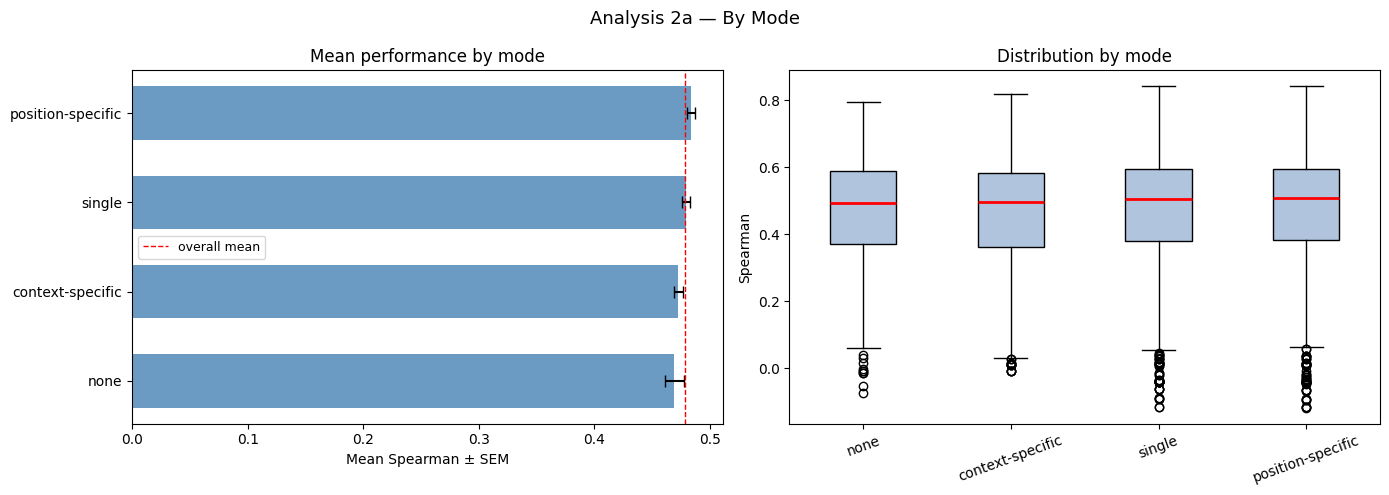

                     mean     std     sem  count
mode                                            
none               0.4691  0.1618  0.0081    394
context-specific   0.4724  0.1586  0.0037   1854
single             0.4793  0.1667  0.0037   2024
position-specific  0.4832  0.1636  0.0034   2375


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analysis 2a — By Mode', fontsize=13)

# mean ± SEM across all datasets & shots
mode_stats = (master_df
              .groupby('mode')['spearman']
              .agg(['mean','std','count'])
              .assign(sem=lambda d: d['std'] / np.sqrt(d['count']))
              .sort_values('mean'))

ax = axes[0]
ax.barh(mode_stats.index, mode_stats['mean'],
        xerr=mode_stats['sem'], color='steelblue', alpha=0.8,
        capsize=4, height=0.6)
ax.axvline(master_df['spearman'].mean(), color='red', linestyle='--', lw=1,
           label='overall mean')
ax.set_xlabel('Mean Spearman ± SEM'); ax.set_title('Mean performance by mode')
ax.legend(fontsize=9)

# box plots per mode
ax = axes[1]
mode_order = master_df.groupby('mode')['spearman'].median().sort_values().index.tolist()
data_boxes = [master_df[master_df['mode'] == m]['spearman'].dropna().values
              for m in mode_order]
bp = ax.boxplot(data_boxes, labels=mode_order, vert=True, patch_artist=True,
                medianprops=dict(color='red', lw=2))
for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')
ax.set_ylabel('Spearman'); ax.set_title('Distribution by mode')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
# plt.savefig('analysis_2a_by_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print(mode_stats[['mean','std','sem','count']].round(4))



By ainit:
          mean     std     sem  count
ainit                               
 0.1   0.4633  0.1733  0.0033   2782
-1.0   0.4911  0.1536  0.0026   3471

By combined:
                           mean     std     sem  count
combined                                             
logits_trainmodefull    0.4781  0.1634  0.0041   1567
scores_trainmodefull    0.4782  0.1635  0.0041   1563
scores_trainmodea_only  0.4792  0.1631  0.0041   1564
logits_trainmodea_only  0.4794  0.1629  0.0041   1559

By trainmode:
              mean     std     sem  count
trainmode                               
full       0.4782  0.1634  0.0029   3130
a_only     0.4793  0.1630  0.0029   3123


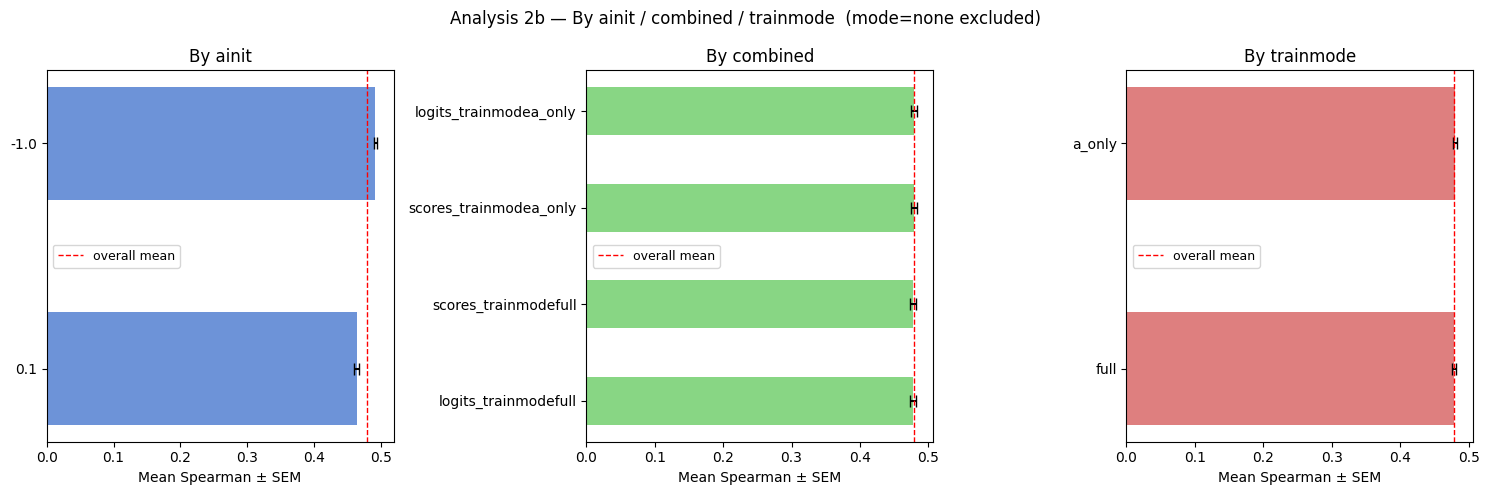

In [17]:
df_no_none = master_df[master_df['mode'] != 'none'].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Analysis 2b — By ainit / combined / trainmode  (mode=none excluded)', fontsize=12)

dims   = ['ainit',            'combined',          'trainmode']
titles = ['By ainit',         'By combined',        'By trainmode']
colors = ['#4878CF', '#6ACC65', '#D65F5F']

for ax, dim, title, color in zip(axes, dims, titles, colors):
    stats_d = (df_no_none
               .groupby(dim)['spearman']
               .agg(['mean','std','count'])
               .assign(sem=lambda d: d['std'] / np.sqrt(d['count']))
               .sort_values('mean'))
    ax.barh(stats_d.index.astype(str), stats_d['mean'],
            xerr=stats_d['sem'], color=color, alpha=0.8, capsize=4, height=0.5)
    ax.axvline(df_no_none['spearman'].mean(), color='red', linestyle='--',
               lw=1, label='overall mean')
    ax.set_xlabel('Mean Spearman ± SEM'); ax.set_title(title)
    ax.legend(fontsize=9)
    print(f"\n{title}:\n", stats_d[['mean','std','sem','count']].round(4))

plt.tight_layout()
# plt.savefig('analysis_2b_dims.png', dpi=150, bbox_inches='tight')
plt.show()


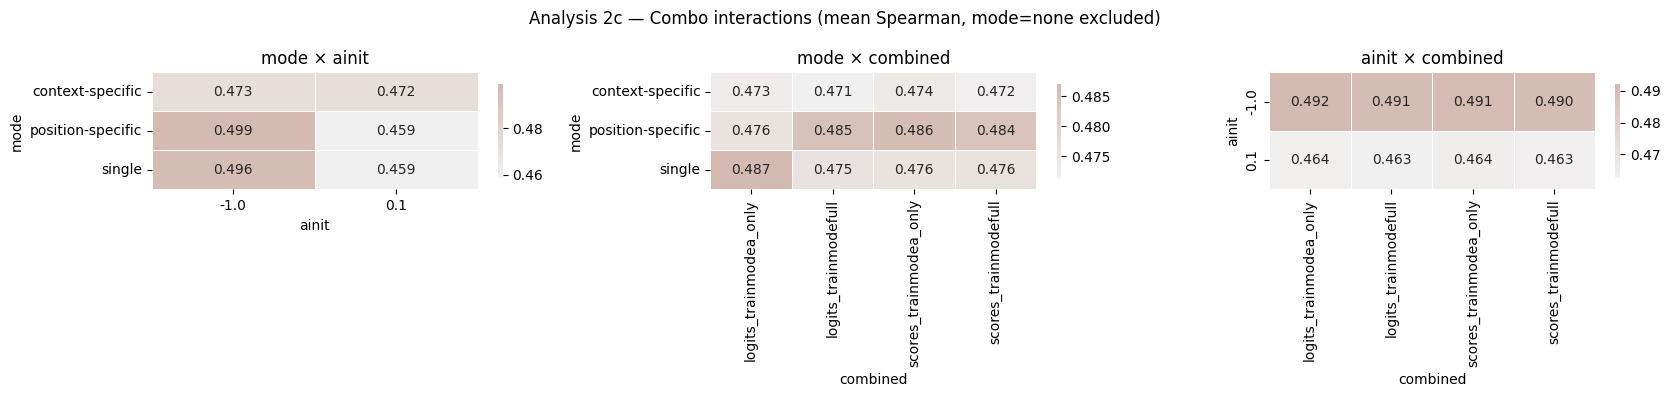

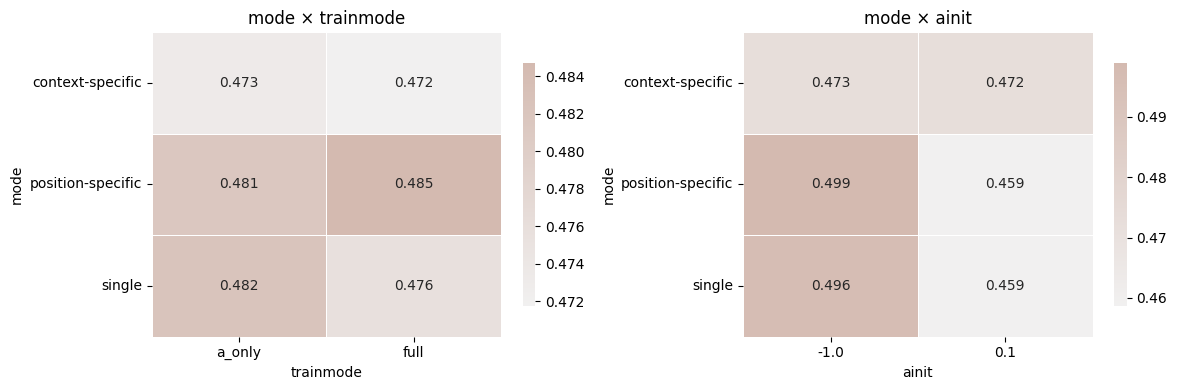

In [22]:
df_nn = master_df[master_df['mode'] != 'none'].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Analysis 2c — Combo interactions (mean Spearman, mode=none excluded)', fontsize=12)

pairs = [('mode', 'ainit'), ('mode', 'combined'), ('ainit', 'combined')]
for ax, (r, c) in zip(axes, pairs):
    hm = df_nn.pivot_table(index=r, columns=c, values='spearman', aggfunc='mean')
    sns.heatmap(hm, ax=ax, cmap=sns.light_palette('#D4BAB0', as_cmap=True),
            annot=True, fmt='.3f', linewidths=0.5, cbar_kws={'shrink': 0.8})

    ax.set_title(f'{r} × {c}')

plt.tight_layout()
# plt.savefig('analysis_2c_interactions.png', dpi=150, bbox_inches='tight')
plt.show()

# mode × trainmode
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, c in zip(axes, ['trainmode', 'ainit']):
    hm = df_nn.pivot_table(index='mode', columns=c, values='spearman', aggfunc='mean')
    sns.heatmap(hm, ax=ax, cmap=sns.light_palette('#D4BAB0', as_cmap=True),
            annot=True, fmt='.3f', linewidths=0.5, cbar_kws={'shrink': 0.8})

    ax.set_title(f'mode × {c}')
plt.tight_layout()
# plt.savefig('analysis_2c_mode_interactions.png', dpi=150, bbox_inches='tight')
plt.show()
